In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import geopandas as gpd
import matplotlib.colors as mcolors
import networkx as nx

In [3]:
domainColors={'Life Sciences':'#81b29a', 'Physical Sciences':'#3d405b', 'Social Sciences':'#e07a5f', 'Health Sciences':'#f4f1de'}

In [4]:
countryDF = pd.read_csv('../data/Floriana_country_info.csv')
id2nameC=dict(zip(countryDF['alpha-2'],countryDF['name']))
id2region=dict(zip(countryDF['alpha-2'],countryDF['region']))
id2subregion=dict(zip(countryDF['alpha-2'],countryDF['sub-region']))

id2nameC['XK']='Kosovo'
id2region['XK']='Europe'
id2subregion['XK']='Southern Europe'

name2iso3=dict(zip(countryDF['name'],countryDF['alpha-3']))

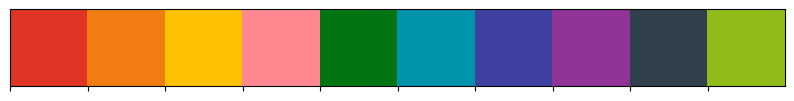

In [5]:
#selCountries=['CN','US','BR','MA','RU','FR','IN','ZA','DE','ID']
#colorsCountries=['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33','#a65628','#f781bf','black',"#0b8076"]
selCountries=['CN','RU','BR','ZA','US','FR','MA','IR','ID']
colorsCountries=['#e03524','#f07c12','#ffc200',"#ff868efa","#037412",'#0095ac','#4040a0','#903498',"#313e4b",'#90bc1a']

coldict = dict(zip(selCountries, colorsCountries))

#plot the palette
sns.palplot(colorsCountries)

In [6]:
dfshare=pd.read_csv('../data/df_box_domain.csv')

In [7]:
dfshare['domain_name'].unique()

array(['Life Sciences', 'Social Sciences', 'Physical Sciences',
       'Health Sciences'], dtype=object)

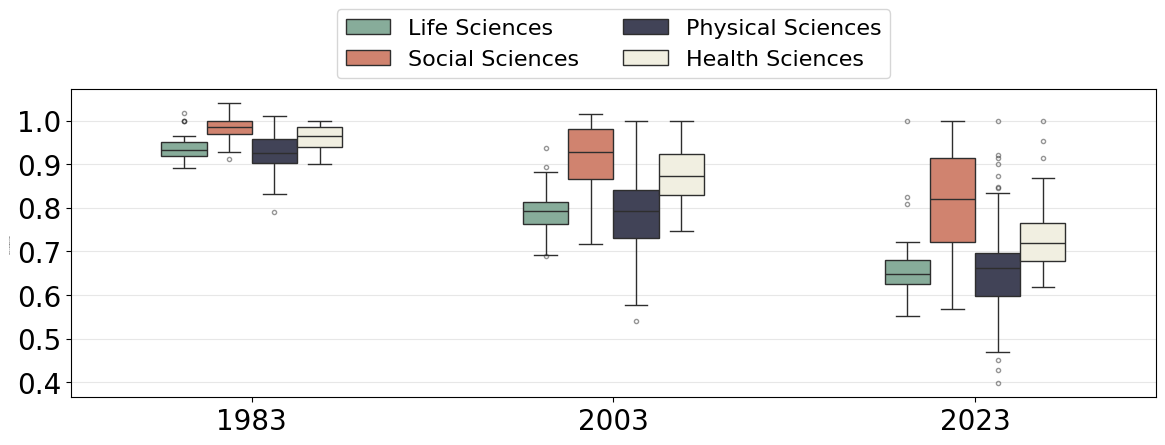

In [8]:
dfshareyy=dfshare[dfshare['year'].isin([1983, 2003, 2023])].copy()
plt.figure(figsize=(14, 4))
sns.boxplot(data=dfshareyy, x='year', y='share_individual', hue='domain_name', width=0.5, showfliers=True,palette=domainColors,flierprops={"marker": "o", "markersize": 3, "alpha": 0.5})
plt.xticks(size=20)
plt.yticks(size=20)
plt.xlabel(None)
plt.ylabel('Share of individual authors', size=0)
plt.legend(fontsize=16, loc="lower center", bbox_to_anchor=(0.5, 1), ncols=2)
plt.grid(axis="y", alpha=0.3)
plt.savefig(f"../domains_v1.jpg", dpi=1000, bbox_inches='tight')

In [9]:
dd=pd.read_csv('../data/df_box_modes.csv')

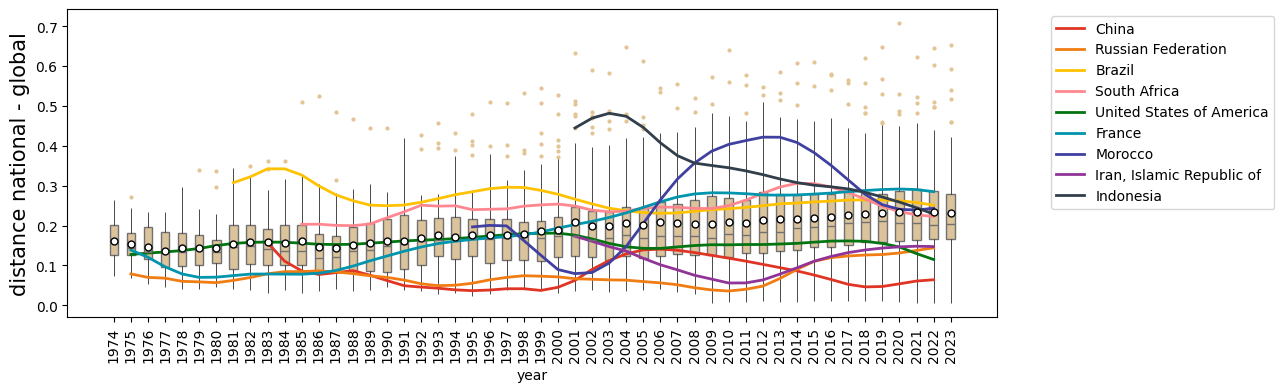

In [10]:
plt.figure(figsize=(12,4))

years = sorted(dd['year'].unique())

sns.boxplot(data=dd, x='year', y='distance', order=years,
            color='#e3c594', width=0.5, showfliers=True, showmeans=True,
            meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"},
            whiskerprops={"color":"black", "linewidth":0.5},
            capprops={"color":"black", "linewidth":0},
            flierprops={"marker":"o", "markerfacecolor":"#e3c594", "markeredgecolor":"#e3c594", "markersize":2},
            saturation=0.8)

for i in selCountries:
    dfTemp = dd[dd['country'] == i].sort_values('year').copy()
    dfTemp['fraction_smooth'] = dfTemp['distance'].rolling(window=3, center=True).mean()
    x_pos = [years.index(y) for y in dfTemp['year']]
    plt.plot(x_pos, dfTemp['fraction_smooth'], color=colorsCountries[selCountries.index(i)],label=id2nameC[i], linewidth=2)
    
plt.legend()
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('distance national - global', size=15)
#plt.grid()
plt.show()

In [11]:
dfProfY=pd.read_csv('../data/df_dist_year.csv')
dfdist=pd.read_csv('../data/df_dist_country.csv')
dfdistI=dfdist[dfdist['mode']=='individual'].copy()
del dfdistI['mode']

In [12]:

# 1. Porta in formato long (solo upper triangle per evitare duplicati)
rows = []
for year, df_year in dfdistI.groupby("year"):
    # Rimuovi le colonne 'country' e 'year' per avere solo la matrice
    mat = df_year.drop(columns=["country", "year"]).set_index(df_year["country"])
    
    
    countries = mat.index.tolist()
    for i, c1 in enumerate(countries):
        for j, c2 in enumerate(countries):
            if j <= i:
                continue
            val = mat.loc[c1, c2]
            if pd.notna(val):
                rows.append({"year": year, "c1": c1, "c2": c2, "distance": val})
                rows.append({"year": year, "c1": c2, "c2": c1, "distance": val})

df_long = pd.DataFrame(rows)


In [13]:
dfInfo = pd.read_csv('../data/countryStats.csv')

In [14]:
nPub={}
for y in dfInfo['year'].unique():
    dfTemp=dfInfo[dfInfo['year']==y]
    nPub[y]=dict(zip(dfTemp['country'], dfTemp['nPapers']))
df_long['nP1']=df_long.apply(lambda row: nPub[row['year']][row['c1']], axis=1)
df_long['nP2']=df_long.apply(lambda row: nPub[row['year']][row['c2']], axis=1)
df_long['prod']=df_long['nP1']*df_long['nP2']

In [15]:
import scipy
def logBinningFunction(xx, yy, num_bins=15):
    logBins=np.logspace(np.log2(np.min(xx)),np.log2(np.max(xx)),base=2,num=num_bins)
    ybin,xbin,binnumber=scipy.stats.binned_statistic(xx,yy,statistic='mean',bins=logBins)
    ystd=scipy.stats.binned_statistic(xx,yy,statistic='std',bins=logBins)[0]
    return xbin, ybin, ystd

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


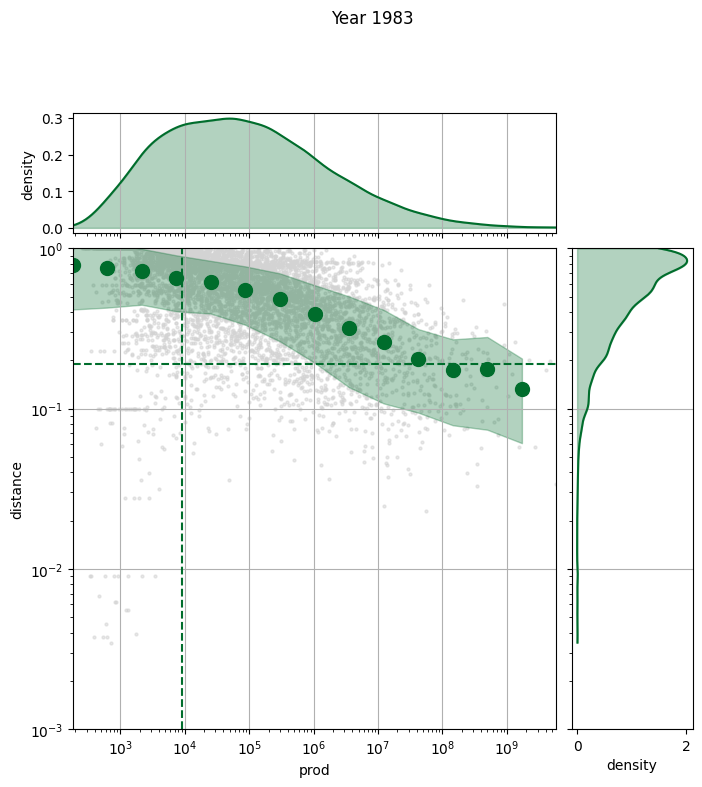

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/3595425431.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c1name'] = dflow['c1'].map(id2nameC)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/3595425431.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c2name'] = dflow['c2'].map(id2nameC)


In [16]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

y = 1983
df_year = df_long[df_long['year'] == y]

color= "#006D2C"

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(2, 2, 
                        width_ratios=[4, 1], 
                        height_ratios=[1, 4],
                        hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# --- plot principale ---
ax_main.scatter(df_year['prod'], df_year['distance'], color='lightgray', alpha=0.3, s=4)
xb, yb, ystd = logBinningFunction(df_year['prod'], df_year['distance'], 15)
ax_main.fill_between(xb[:-1], yb-ystd, yb+ystd, color=color, alpha=0.3)
ax_main.plot(xb[:-1], yb, 'o', markersize=10, color=color)
ax_main.set_xscale('log')
ax_main.set_yscale('log')
ax_main.set_ylim(0.001, 1)
ax_main.set_xlabel('prod')
ax_main.set_ylabel('distance')
ax_main.grid()

# --- KDE prod (in alto) ---
log_prod = np.log10(df_year['prod'].dropna())
log_prod = log_prod[np.isfinite(log_prod)]
kde_prod = gaussian_kde(log_prod)
x_grid = np.linspace(log_prod.min(), log_prod.max(), 300)
ax_top.plot(10**x_grid, kde_prod(x_grid), color=color)
ax_top.fill_between(10**x_grid, kde_prod(x_grid), alpha=0.3, color=color)
ax_top.set_xscale('log')
ax_top.set_ylabel('density')
ax_top.tick_params(labelbottom=False)
ax_top.grid(axis='x')

# --- KDE distance (a destra) ---
log_dist = np.log10(df_year['distance'].dropna())
log_dist = log_dist[np.isfinite(log_dist)]
kde_dist = gaussian_kde(log_dist)
y_grid = np.linspace(log_dist.min(), log_dist.max(), 300)
ax_right.plot(kde_dist(y_grid), 10**y_grid, color=color)
ax_right.fill_betweenx(10**y_grid, kde_dist(y_grid), alpha=0.3, color=color)
ax_right.set_yscale('log')
ax_right.set_xlabel('density')
ax_right.tick_params(labelleft=False)
ax_right.grid(axis='y')

q_prod = df_year['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year['distance'].quantile(0.10)  # bottom 25%
mask = (df_year['prod'] < q_prod) & (df_year['distance'] < q_dist)
ax_main.vlines(x=q_prod, ymin=0.001, ymax=1, color=color, linestyle='--')
ax_main.hlines(y=q_dist, xmin=df_year['prod'].min(), xmax=df_year['prod'].max(), color=color, linestyle='--')
ax_main.set_xlim(xmin=df_year['prod'].min(), xmax=df_year['prod'].max())
plt.suptitle(f'Year {y}', y=1.01)



plt.suptitle(f'Year {y}', y=1.01)
plt.show()


dflow = df_year[mask]
dflow['c1name'] = dflow['c1'].map(id2nameC)
dflow['c2name'] = dflow['c2'].map(id2nameC)
G=nx.from_pandas_edgelist(dflow, source='c1name', target='c2name', create_using=nx.Graph())
nx.write_gexf(G, f'graph_{y}.gexf')

In [17]:
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

y = 1983
df_year_1983 = df_long[df_long['year'] == y]

q_prod = df_year_1983['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year_1983['distance'].quantile(0.10)  # bottom 25%
mask = (df_year_1983['prod'] < q_prod) & (df_year_1983['distance'] < q_dist)

dflow = df_year_1983[mask]
dflow['c1name'] = dflow['c1'].map(id2nameC)
dflow['c2name'] = dflow['c2'].map(id2nameC)

G1983=nx.from_pandas_edgelist(dflow, source='c1name', target='c2name', create_using=nx.Graph())
nx.write_gexf(G1983, f'graph_{y}.gexf')

cc=nx.connected_components(G1983)
#transform in a dataframe
df_cc = pd.DataFrame({'country': list(G1983.nodes), 'component': [0]*len(G1983.nodes)})
for i, comp in enumerate(cc):
    if len(comp)>2:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = i+1 
    else:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = 0   

df_cc['ISO3']=df_cc['country'].map(name2iso3)

#merge with df_cc (quello non presente avrà component 0)
world1983 = world.copy().merge(df_cc, how="left", left_on="ISO_A3", right_on="ISO3")
world1983 = world1983[world1983["CONTINENT"] != "Antarctica"]
world1983["component"] = world1983["component"].fillna(0)


#merge with df_cc (quello non presente avrà component 0)
y = 2023
df_year_2023 = df_long[df_long['year'] == y]

q_prod = df_year_2023['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year_2023['distance'].quantile(0.10)  # bottom 25%
mask = (df_year_2023['prod'] < q_prod) & (df_year_2023['distance'] < q_dist)

dflow = df_year_2023[mask]
dflow['c1name'] = dflow['c1'].map(id2nameC)
dflow['c2name'] = dflow['c2'].map(id2nameC)

G2023=nx.from_pandas_edgelist(dflow, source='c1name', target='c2name', create_using=nx.Graph())
nx.write_gexf(G2023, f'graph_{y}.gexf')

cc=nx.connected_components(G2023)
#transform in a dataframe
df_cc = pd.DataFrame({'country': list(G2023.nodes), 'component': [0]*len(G2023.nodes)})
for i, comp in enumerate(cc):
    if len(comp)>2:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = i+1 
    else:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = 0   

df_cc['ISO3']=df_cc['country'].map(name2iso3)


world2023 = world.copy().merge(df_cc, how="left", left_on="ISO_A3", right_on="ISO3")
world2023 = world2023[world2023["CONTINENT"] != "Antarctica"]
world2023["component"] = world2023["component"].fillna(0)

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/2749562139.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c1name'] = dflow['c1'].map(id2nameC)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/2749562139.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c2name'] = dflow['c2'].map(id2nameC)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/2749562139.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [18]:
colors = [
    "lightgray",
    "#2E4057",  # Blu notte
    "#C1440E",  # Terracotta
    "#4A7C59",  # Verde salvia
    "#8B5E3C",  # Marrone caldo
    "#6B4C82",  # Viola scuro
    "#C49A3C",  # Ocra dorata
    "#2A7F8F",  # Teal profondo
    "#B5432A",  # Rosso mattone
    "#5C7A3E",  # Verde oliva
    "#7A3B4B",  # Bordeaux
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=range(len(colors) + 1), ncolors=len(colors))

In [19]:
base_fontsize= 16

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


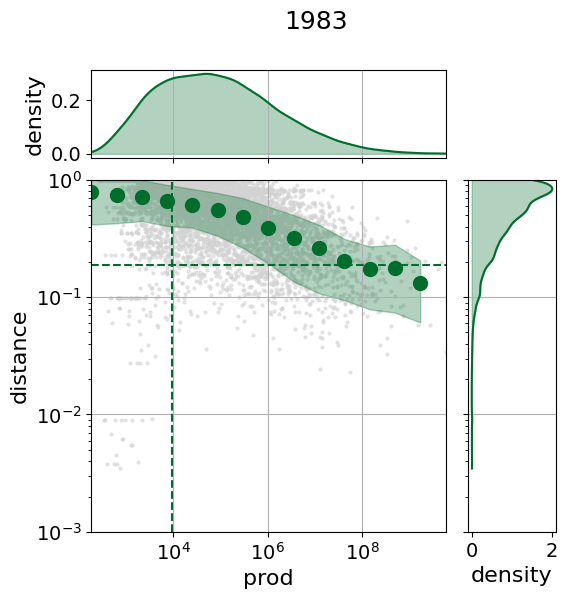

In [20]:
fig = plt.figure(figsize=(6, 6))
inner_1 = fig.add_gridspec(
    2,2,
    width_ratios=[4,1],
    height_ratios=[1,4],
    wspace=0.1, hspace=0.1
)

ax_main_1  = fig.add_subplot(inner_1[1,0])
ax_top_1   = fig.add_subplot(inner_1[0,0], sharex=ax_main_1)
ax_right_1 = fig.add_subplot(inner_1[1,1], sharey=ax_main_1)

color= "#006D2C"

# --- plot principale ---
ax_main_1.scatter(df_year_1983['prod'], df_year_1983['distance'], color='lightgray', alpha=0.3, s=4)
xb, yb, ystd = logBinningFunction(df_year_1983['prod'], df_year_1983['distance'], 15)
ax_main_1.fill_between(xb[:-1], yb-ystd, yb+ystd, color=color, alpha=0.3)
ax_main_1.plot(xb[:-1], yb, 'o', markersize=10, color=color)
ax_main_1.set_xscale('log')
ax_main_1.set_yscale('log')
ax_main_1.set_ylim(0.001, 1)
ax_main_1.set_xlabel('prod', fontdict={"size": base_fontsize})
ax_main_1.set_ylabel('distance', fontdict={"size": base_fontsize})
ax_main_1.tick_params(axis='both', labelsize=base_fontsize-2)
ax_main_1.grid()

log_prod = np.log10(df_year_1983['prod'].dropna())
log_prod = log_prod[np.isfinite(log_prod)]
kde_prod = gaussian_kde(log_prod)
x_grid = np.linspace(log_prod.min(), log_prod.max(), 300)
ax_top_1.plot(10**x_grid, kde_prod(x_grid), color=color)
ax_top_1.fill_between(10**x_grid, kde_prod(x_grid), alpha=0.3, color=color)
ax_top_1.set_xscale('log')
ax_top_1.set_ylabel('density', fontdict={"size": base_fontsize})
ax_top_1.tick_params(labelbottom=False, labelsize=base_fontsize-2)
ax_top_1.grid(axis='x')

log_dist = np.log10(df_year_1983['distance'].dropna())
log_dist = log_dist[np.isfinite(log_dist)]
kde_dist = gaussian_kde(log_dist)
y_grid = np.linspace(log_dist.min(), log_dist.max(), 300)
ax_right_1.plot(kde_dist(y_grid), 10**y_grid, color=color)
ax_right_1.fill_betweenx(10**y_grid, kde_dist(y_grid), alpha=0.3, color=color)
ax_right_1.set_yscale('log')
ax_right_1.set_xlabel('density', fontdict={"size": base_fontsize})
ax_right_1.tick_params(labelleft=False, labelsize=base_fontsize-2)
ax_right_1.grid(axis='y')

q_prod = df_year_1983['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year_1983['distance'].quantile(0.10)  # bottom 25%
mask = (df_year_1983['prod'] < q_prod) & (df_year_1983['distance'] < q_dist)
ax_main_1.vlines(x=q_prod, ymin=0.001, ymax=1, color=color, linestyle='--')
ax_main_1.hlines(y=q_dist, xmin=df_year_1983['prod'].min(), xmax=df_year_1983['prod'].max(), color=color, linestyle='--')
ax_main_1.set_xlim(xmin=df_year_1983['prod'].min(), xmax=df_year_1983['prod'].max())


# ax1 = fig.add_subplot(outer[0, 1])
# fig.set_title("1983", fontdict={"size": base_fontsize+2})
fig.suptitle("1983", fontsize=base_fontsize + 2)
# ax11.set_axis_off()
fig.savefig(f"../distributions_1983_v1.jpg", dpi=1000, bbox_inches='tight')

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


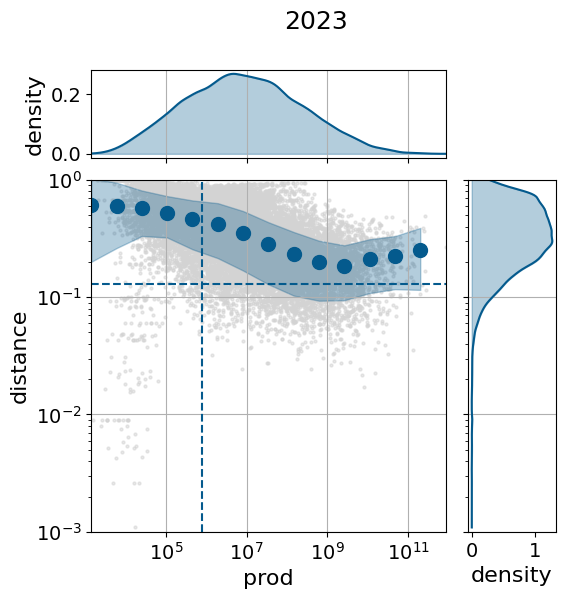

In [21]:
fig = plt.figure(figsize=(6, 6))
inner_1 = fig.add_gridspec(
    2,2,
    width_ratios=[4,1],
    height_ratios=[1,4],
    wspace=0.1, hspace=0.1
)

ax_main_1  = fig.add_subplot(inner_1[1,0])
ax_top_1   = fig.add_subplot(inner_1[0,0], sharex=ax_main_1)
ax_right_1 = fig.add_subplot(inner_1[1,1], sharey=ax_main_1)

color= "#045A8D"

# --- plot principale ---
ax_main_1.scatter(df_year_2023['prod'], df_year_2023['distance'], color='lightgray', alpha=0.3, s=4)
xb, yb, ystd = logBinningFunction(df_year_2023['prod'], df_year_2023['distance'], 15)
ax_main_1.fill_between(xb[:-1], yb-ystd, yb+ystd, color=color, alpha=0.3)
ax_main_1.plot(xb[:-1], yb, 'o', markersize=10, color=color)
ax_main_1.set_xscale('log')
ax_main_1.set_yscale('log')
ax_main_1.set_ylim(0.001, 1)
ax_main_1.set_xlabel('prod', fontdict={"size": base_fontsize})
ax_main_1.set_ylabel('distance', fontdict={"size": base_fontsize})
ax_main_1.tick_params(axis='both', labelsize=base_fontsize-2)
ax_main_1.grid()

log_prod = np.log10(df_year_2023['prod'].dropna())
log_prod = log_prod[np.isfinite(log_prod)]
kde_prod = gaussian_kde(log_prod)
x_grid = np.linspace(log_prod.min(), log_prod.max(), 300)
ax_top_1.plot(10**x_grid, kde_prod(x_grid), color=color)
ax_top_1.fill_between(10**x_grid, kde_prod(x_grid), alpha=0.3, color=color)
ax_top_1.set_xscale('log')
ax_top_1.set_ylabel('density', fontdict={"size": base_fontsize})
ax_top_1.tick_params(labelbottom=False, labelsize=base_fontsize-2)
ax_top_1.grid(axis='x')

log_dist = np.log10(df_year_2023['distance'].dropna())
log_dist = log_dist[np.isfinite(log_dist)]
kde_dist = gaussian_kde(log_dist)
y_grid = np.linspace(log_dist.min(), log_dist.max(), 300)
ax_right_1.plot(kde_dist(y_grid), 10**y_grid, color=color)
ax_right_1.fill_betweenx(10**y_grid, kde_dist(y_grid), alpha=0.3, color=color)
ax_right_1.set_yscale('log')
ax_right_1.set_xlabel('density', fontdict={"size": base_fontsize})
ax_right_1.tick_params(labelleft=False, labelsize=base_fontsize-2)
ax_right_1.grid(axis='y')

q_prod = df_year_2023['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year_2023['distance'].quantile(0.10)  # bottom 25%
mask = (df_year_2023['prod'] < q_prod) & (df_year_2023['distance'] < q_dist)
ax_main_1.vlines(x=q_prod, ymin=0.001, ymax=1, color=color, linestyle='--')
ax_main_1.hlines(y=q_dist, xmin=df_year_2023['prod'].min(), xmax=df_year_2023['prod'].max(), color=color, linestyle='--')
ax_main_1.set_xlim(xmin=df_year_2023['prod'].min(), xmax=df_year_2023['prod'].max())


# ax1 = fig.add_subplot(outer[0, 1])
# fig.set_title("1983", fontdict={"size": base_fontsize+2})
fig.suptitle("2023", fontsize=base_fontsize + 2)
# ax11.set_axis_off()
fig.savefig(f"../distributions_2023_v1.jpg", dpi=1000, bbox_inches='tight')

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


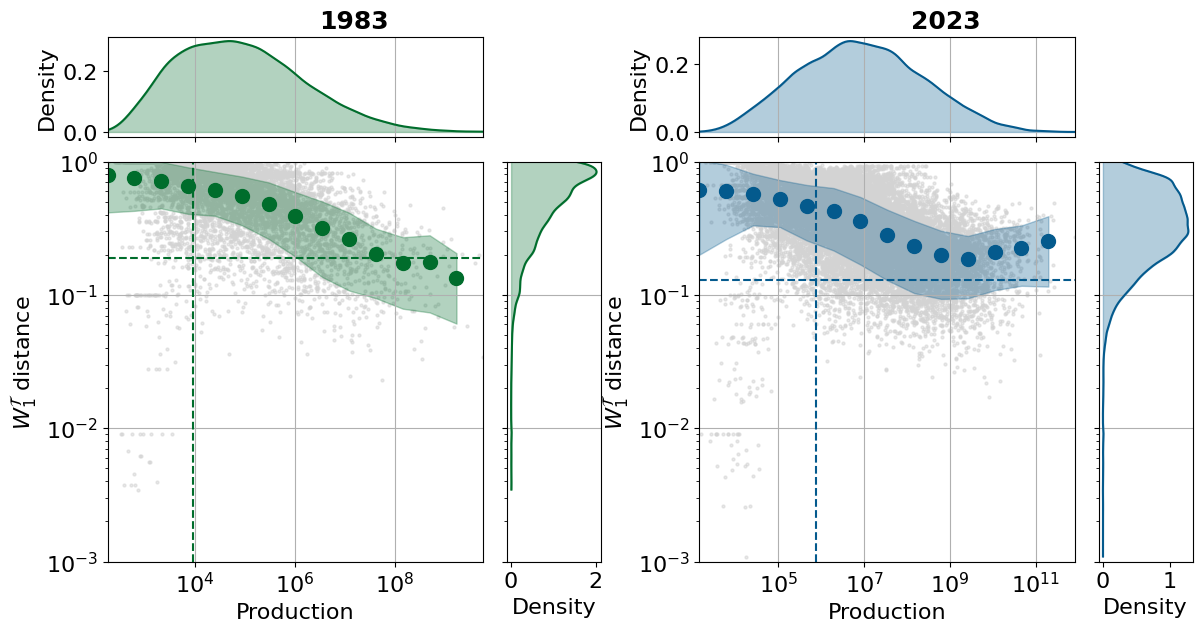

In [22]:
fig = plt.figure(figsize=(14,12))

base_fontsize = 16

outer = fig.add_gridspec(2, 2, height_ratios=[2, 1.2])

ax11 = fig.add_subplot(outer[0, 0])
inner_1 = outer[0,0].subgridspec(
    2,2,
    width_ratios=[4,1],
    height_ratios=[1,4],
    wspace=0.1, hspace=0.1
)

ax_main_1  = fig.add_subplot(inner_1[1,0])
ax_top_1   = fig.add_subplot(inner_1[0,0], sharex=ax_main_1)
ax_right_1 = fig.add_subplot(inner_1[1,1], sharey=ax_main_1)

color= "#006D2C"

# --- plot principale ---
ax_main_1.scatter(df_year_1983['prod'], df_year_1983['distance'], color='lightgray', alpha=0.3, s=4)
xb, yb, ystd = logBinningFunction(df_year_1983['prod'], df_year_1983['distance'], 15)
ax_main_1.fill_between(xb[:-1], yb-ystd, yb+ystd, color=color, alpha=0.3)
ax_main_1.plot(xb[:-1], yb, 'o', markersize=10, color=color)
ax_main_1.set_xscale('log')
ax_main_1.set_yscale('log')
ax_main_1.set_ylim(0.001, 1)
ax_main_1.set_xlabel('Production', fontsize=base_fontsize)
ax_main_1.set_ylabel(r'$W_1^{\mathcal{T}}$ distance', fontsize=base_fontsize)
ax_main_1.tick_params(axis='both', labelsize=base_fontsize)
ax_main_1.grid()

log_prod = np.log10(df_year_1983['prod'].dropna())
log_prod = log_prod[np.isfinite(log_prod)]
kde_prod = gaussian_kde(log_prod)
x_grid = np.linspace(log_prod.min(), log_prod.max(), 300)
ax_top_1.plot(10**x_grid, kde_prod(x_grid), color=color)
ax_top_1.fill_between(10**x_grid, kde_prod(x_grid), alpha=0.3, color=color)
ax_top_1.set_xscale('log')
ax_top_1.set_ylabel('Density', fontdict={"size": base_fontsize})
ax_top_1.tick_params(labelbottom=False, labelsize=base_fontsize)
ax_top_1.grid(axis='x')

log_dist = np.log10(df_year_1983['distance'].dropna())
log_dist = log_dist[np.isfinite(log_dist)]
kde_dist = gaussian_kde(log_dist)
y_grid = np.linspace(log_dist.min(), log_dist.max(), 300)
ax_right_1.plot(kde_dist(y_grid), 10**y_grid, color=color)
ax_right_1.fill_betweenx(10**y_grid, kde_dist(y_grid), alpha=0.3, color=color)
ax_right_1.set_yscale('log')
ax_right_1.set_xlabel('Density', fontdict={"size": base_fontsize})
ax_right_1.tick_params(labelleft=False, labelsize=base_fontsize)
ax_right_1.grid(axis='y')

q_prod = df_year_1983['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year_1983['distance'].quantile(0.10)  # bottom 25%
mask = (df_year_1983['prod'] < q_prod) & (df_year_1983['distance'] < q_dist)
ax_main_1.vlines(x=q_prod, ymin=0.001, ymax=1, color=color, linestyle='--')
ax_main_1.hlines(y=q_dist, xmin=df_year_1983['prod'].min(), xmax=df_year_1983['prod'].max(), color=color, linestyle='--')
ax_main_1.set_xlim(xmin=df_year_1983['prod'].min(), xmax=df_year_1983['prod'].max())


# ax1 = fig.add_subplot(outer[0, 1])
ax11.set_title("1983", fontdict={"size": base_fontsize+2, "weight": "bold"})
ax11.set_axis_off()

# ax12 = fig.add_subplot(outer[0,1])
ax12 = fig.add_subplot(outer[0, 1])
inner_2 = outer[0,1].subgridspec(
    2,2,
    width_ratios=[4,1],
    height_ratios=[1,4],
    wspace=0.1, hspace=0.1
)

ax_main_2  = fig.add_subplot(inner_2[1, 0])
ax_top_2   = fig.add_subplot(inner_2[0,0], sharex=ax_main_2)
ax_right_2 = fig.add_subplot(inner_2[1,1], sharey=ax_main_2)

color="#045A8D"

ax_main_2.scatter(df_year_2023['prod'], df_year_2023['distance'], color='lightgray', alpha=0.3, s=4)
xb, yb, ystd = logBinningFunction(df_year_2023['prod'], df_year_2023['distance'], 15)
ax_main_2.fill_between(xb[:-1], yb-ystd, yb+ystd, color=color, alpha=0.3)
ax_main_2.plot(xb[:-1], yb, 'o', markersize=10, color=color)
ax_main_2.set_xscale('log')
ax_main_2.set_yscale('log')
ax_main_2.set_ylim(0.001, 1)
ax_main_2.set_xlabel('Production', fontsize=base_fontsize)
ax_main_2.set_ylabel(r'$W_1^{\mathcal{T}}$ distance', fontsize=base_fontsize)
ax_main_2.tick_params(axis='both', labelsize=base_fontsize)
ax_main_2.grid()

log_prod = np.log10(df_year_2023['prod'].dropna())
log_prod = log_prod[np.isfinite(log_prod)]
kde_prod = gaussian_kde(log_prod)
x_grid = np.linspace(log_prod.min(), log_prod.max(), 300)
ax_top_2.plot(10**x_grid, kde_prod(x_grid), color=color)
ax_top_2.fill_between(10**x_grid, kde_prod(x_grid), alpha=0.3, color=color)
ax_top_2.set_xscale('log')
ax_top_2.set_ylabel('Density', fontsize=base_fontsize)
ax_top_2.tick_params(labelbottom=False, labelsize=base_fontsize)
ax_top_2.grid(axis='x')

log_dist = np.log10(df_year_2023['distance'].dropna())
log_dist = log_dist[np.isfinite(log_dist)]
kde_dist = gaussian_kde(log_dist)
y_grid = np.linspace(log_dist.min(), log_dist.max(), 300)
ax_right_2.plot(kde_dist(y_grid), 10**y_grid, color=color)
ax_right_2.fill_betweenx(10**y_grid, kde_dist(y_grid), alpha=0.3, color=color)
ax_right_2.set_yscale('log')
ax_right_2.set_xlabel('Density', fontsize=base_fontsize)
ax_right_2.tick_params(labelleft=False, labelsize=base_fontsize)
ax_right_2.grid(axis='y')

q_prod = df_year_2023['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year_2023['distance'].quantile(0.10)  # bottom 25%
mask = (df_year_2023['prod'] < q_prod) & (df_year_2023['distance'] < q_dist)
ax_main_2.vlines(x=q_prod, ymin=0.001, ymax=1, color=color, linestyle='--')
ax_main_2.hlines(y=q_dist, xmin=df_year_2023['prod'].min(), xmax=df_year_2023['prod'].max(), color=color, linestyle='--')
ax_main_2.set_xlim(xmin=df_year_2023['prod'].min(), xmax=df_year_2023['prod'].max())

ax12.set_title("2023", fontdict={"size": base_fontsize+2, "weight": "bold"})
ax12.set_axis_off()

fig.savefig(f"../distributions_all_v1.jpg", dpi=1000, bbox_inches='tight')

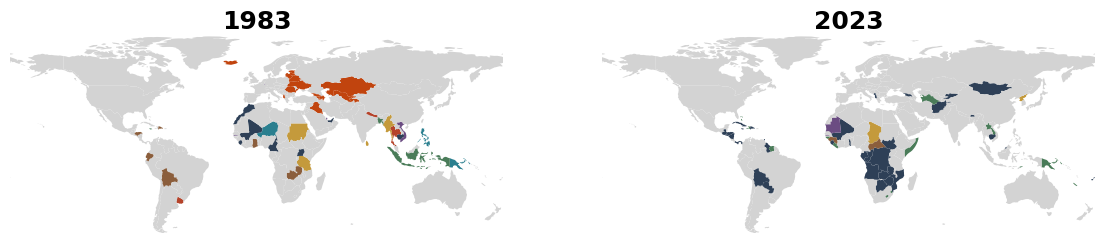

In [23]:
fig = plt.figure(figsize=(14,12))

base_fontsize = 16

outer = fig.add_gridspec(1, 2)

ax13 = fig.add_subplot(outer[0])

world1983.plot(column="component", ax=ax13, cmap=cmap, norm=norm)
#remove axis
ax13.set_axis_off()
ax13.margins(0)
ax13.set_title("1983", fontdict={"size": base_fontsize+2, "weight": "bold"})

ax14 = fig.add_subplot(outer[1])

world2023.plot(column="component", ax=ax14, cmap=cmap, norm=norm)
#remove axis
ax14.set_axis_off()
ax14.margins(0)
ax14.set_title("2023", fontdict={"size": base_fontsize+2, "weight": "bold"})
fig.savefig(f"../map_niches_all_v1.jpg", dpi=1000, bbox_inches='tight')

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


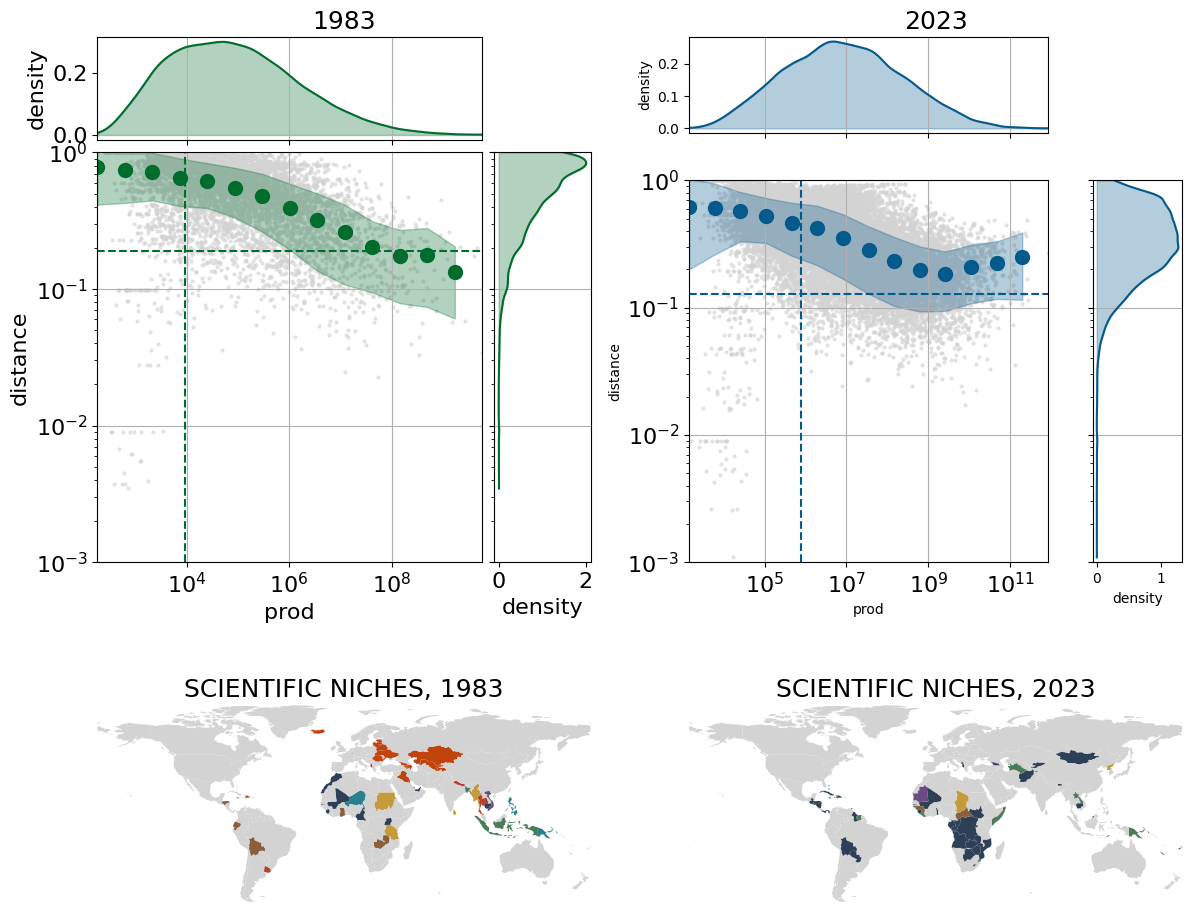

In [24]:
fig = plt.figure(figsize=(14,12))

base_fontsize = 16

outer = fig.add_gridspec(2, 2, height_ratios=[2, 1.2])

ax11 = fig.add_subplot(outer[0, 0])
inner_1 = outer[0,0].subgridspec(
    2,2,
    width_ratios=[4,1],
    height_ratios=[1,4],
    wspace=0.05, hspace=0.05
)

ax_main_1  = fig.add_subplot(inner_1[1,0])
ax_top_1   = fig.add_subplot(inner_1[0,0], sharex=ax_main_1)
ax_right_1 = fig.add_subplot(inner_1[1,1], sharey=ax_main_1)

color= "#006D2C"

# --- plot principale ---
ax_main_1.scatter(df_year_1983['prod'], df_year_1983['distance'], color='lightgray', alpha=0.3, s=4)
xb, yb, ystd = logBinningFunction(df_year_1983['prod'], df_year_1983['distance'], 15)
ax_main_1.fill_between(xb[:-1], yb-ystd, yb+ystd, color=color, alpha=0.3)
ax_main_1.plot(xb[:-1], yb, 'o', markersize=10, color=color)
ax_main_1.set_xscale('log')
ax_main_1.set_yscale('log')
ax_main_1.set_ylim(0.001, 1)
ax_main_1.set_xlabel('prod', fontdict={"size": base_fontsize})
ax_main_1.set_ylabel('distance', fontdict={"size": base_fontsize})
ax_main_1.tick_params(axis='both', labelsize=base_fontsize)
ax_main_1.grid()

log_prod = np.log10(df_year_1983['prod'].dropna())
log_prod = log_prod[np.isfinite(log_prod)]
kde_prod = gaussian_kde(log_prod)
x_grid = np.linspace(log_prod.min(), log_prod.max(), 300)
ax_top_1.plot(10**x_grid, kde_prod(x_grid), color=color)
ax_top_1.fill_between(10**x_grid, kde_prod(x_grid), alpha=0.3, color=color)
ax_top_1.set_xscale('log')
ax_top_1.set_ylabel('density', fontdict={"size": base_fontsize})
ax_top_1.tick_params(labelbottom=False, labelsize=base_fontsize)
ax_top_1.grid(axis='x')

log_dist = np.log10(df_year_1983['distance'].dropna())
log_dist = log_dist[np.isfinite(log_dist)]
kde_dist = gaussian_kde(log_dist)
y_grid = np.linspace(log_dist.min(), log_dist.max(), 300)
ax_right_1.plot(kde_dist(y_grid), 10**y_grid, color=color)
ax_right_1.fill_betweenx(10**y_grid, kde_dist(y_grid), alpha=0.3, color=color)
ax_right_1.set_yscale('log')
ax_right_1.set_xlabel('density', fontdict={"size": base_fontsize})
ax_right_1.tick_params(labelleft=False, labelsize=base_fontsize)
ax_right_1.grid(axis='y')

q_prod = df_year_1983['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year_1983['distance'].quantile(0.10)  # bottom 25%
mask = (df_year_1983['prod'] < q_prod) & (df_year_1983['distance'] < q_dist)
ax_main_1.vlines(x=q_prod, ymin=0.001, ymax=1, color=color, linestyle='--')
ax_main_1.hlines(y=q_dist, xmin=df_year_1983['prod'].min(), xmax=df_year_1983['prod'].max(), color=color, linestyle='--')
ax_main_1.set_xlim(xmin=df_year_1983['prod'].min(), xmax=df_year_1983['prod'].max())


# ax1 = fig.add_subplot(outer[0, 1])
ax11.set_title("1983", fontdict={"size": base_fontsize+2})
ax11.set_axis_off()

# ax12 = fig.add_subplot(outer[0,1])
ax12 = fig.add_subplot(outer[0, 1])
inner_2 = outer[0,1].subgridspec(
    2,2,
    width_ratios=[4,1],
    height_ratios=[1,4]
)

ax_main_2  = fig.add_subplot(inner_2[1, 0])
ax_top_2   = fig.add_subplot(inner_2[0,0], sharex=ax_main_2)
ax_right_2 = fig.add_subplot(inner_2[1,1], sharey=ax_main_2)

color="#045A8D"

ax_main_2.scatter(df_year_2023['prod'], df_year_2023['distance'], color='lightgray', alpha=0.3, s=4)
xb, yb, ystd = logBinningFunction(df_year_2023['prod'], df_year_2023['distance'], 15)
ax_main_2.fill_between(xb[:-1], yb-ystd, yb+ystd, color=color, alpha=0.3)
ax_main_2.plot(xb[:-1], yb, 'o', markersize=10, color=color)
ax_main_2.set_xscale('log')
ax_main_2.set_yscale('log')
ax_main_2.set_ylim(0.001, 1)
ax_main_2.set_xlabel('prod')
ax_main_2.set_ylabel('distance')
ax_main_2.tick_params(axis='both', labelsize=base_fontsize)
ax_main_2.grid()

log_prod = np.log10(df_year_2023['prod'].dropna())
log_prod = log_prod[np.isfinite(log_prod)]
kde_prod = gaussian_kde(log_prod)
x_grid = np.linspace(log_prod.min(), log_prod.max(), 300)
ax_top_2.plot(10**x_grid, kde_prod(x_grid), color=color)
ax_top_2.fill_between(10**x_grid, kde_prod(x_grid), alpha=0.3, color=color)
ax_top_2.set_xscale('log')
ax_top_2.set_ylabel('density')
ax_top_2.tick_params(labelbottom=False)
ax_top_2.grid(axis='x')

log_dist = np.log10(df_year_2023['distance'].dropna())
log_dist = log_dist[np.isfinite(log_dist)]
kde_dist = gaussian_kde(log_dist)
y_grid = np.linspace(log_dist.min(), log_dist.max(), 300)
ax_right_2.plot(kde_dist(y_grid), 10**y_grid, color=color)
ax_right_2.fill_betweenx(10**y_grid, kde_dist(y_grid), alpha=0.3, color=color)
ax_right_2.set_yscale('log')
ax_right_2.set_xlabel('density')
ax_right_2.tick_params(labelleft=False)
ax_right_2.grid(axis='y')

q_prod = df_year_2023['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year_2023['distance'].quantile(0.10)  # bottom 25%
mask = (df_year_2023['prod'] < q_prod) & (df_year_2023['distance'] < q_dist)
ax_main_2.vlines(x=q_prod, ymin=0.001, ymax=1, color=color, linestyle='--')
ax_main_2.hlines(y=q_dist, xmin=df_year_2023['prod'].min(), xmax=df_year_2023['prod'].max(), color=color, linestyle='--')
ax_main_2.set_xlim(xmin=df_year_2023['prod'].min(), xmax=df_year_2023['prod'].max())

ax12.set_title("2023", fontdict={"size": base_fontsize+2})
ax12.set_axis_off()

ax13 = fig.add_subplot(outer[1,0])

world1983.plot(column="component", ax=ax13, cmap=cmap, norm=norm)
#remove axis
ax13.set_axis_off()
ax13.margins(0)
ax13.set_title("SCIENTIFIC NICHES, 1983", fontdict={"size": base_fontsize+2})

ax14 = fig.add_subplot(outer[1,1])

world2023.plot(column="component", ax=ax14, cmap=cmap, norm=norm)
#remove axis
ax14.set_axis_off()
ax14.margins(0)
ax14.set_title("SCIENTIFIC NICHES, 2023", fontdict={"size": base_fontsize+2})

fig.savefig(f"../distributions_all_v1.jpg", dpi=1000, bbox_inches='tight')

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/330036008.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c1name'] = dflow['c1'].map(id2nameC)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/330036008.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c2name'] = dflow['c2'].map(id2nameC)


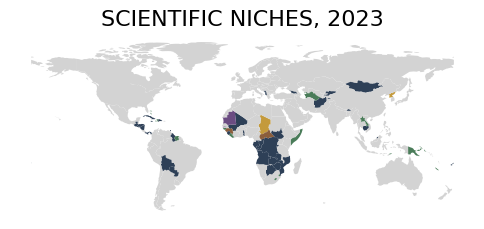

In [25]:
y = 2023
df_year = df_long[df_long['year'] == y]

q_prod = df_year['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year['distance'].quantile(0.10)  # bottom 25%
mask = (df_year['prod'] < q_prod) & (df_year['distance'] < q_dist)

dflow = df_year[mask]
dflow['c1name'] = dflow['c1'].map(id2nameC)
dflow['c2name'] = dflow['c2'].map(id2nameC)

G=nx.from_pandas_edgelist(dflow, source='c1name', target='c2name', create_using=nx.Graph())
nx.write_gexf(G, f'graph_{y}.gexf')

cc=nx.connected_components(G)
#transform in a dataframe
df_cc = pd.DataFrame({'country': list(G.nodes), 'component': [0]*len(G.nodes)})
for i, comp in enumerate(cc):
    if len(comp)>2:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = i+1 
    else:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = 0   

df_cc['ISO3']=df_cc['country'].map(name2iso3)

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world = world[world["CONTINENT"] != "Antarctica"]
#merge with df_cc (quello non presente avrà component 0)
world = world.merge(df_cc, how="left", left_on="ISO_A3", right_on="ISO3")
world["component"] = world["component"].fillna(0)

colors = [
    "lightgray",
    "#2E4057",  # Blu notte
    "#C1440E",  # Terracotta
    "#4A7C59",  # Verde salvia
    "#8B5E3C",  # Marrone caldo
    "#6B4C82",  # Viola scuro
    "#C49A3C",  # Ocra dorata
    "#2A7F8F",  # Teal profondo
    "#B5432A",  # Rosso mattone
    "#5C7A3E",  # Verde oliva
    "#7A3B4B",  # Bordeaux
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=range(len(colors) + 1), ncolors=len(colors))

fig, ax = plt.subplots(figsize=(6, 4))
world.plot(column="component", ax=ax, cmap=cmap, norm=norm)
#remove axis
ax.set_axis_off()
ax.set_title(f"SCIENTIFIC NICHES, {y}", fontsize=base_fontsize)

fig.savefig(f"../map_niches_{y}_v1.jpg", dpi=1000, bbox_inches='tight')

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


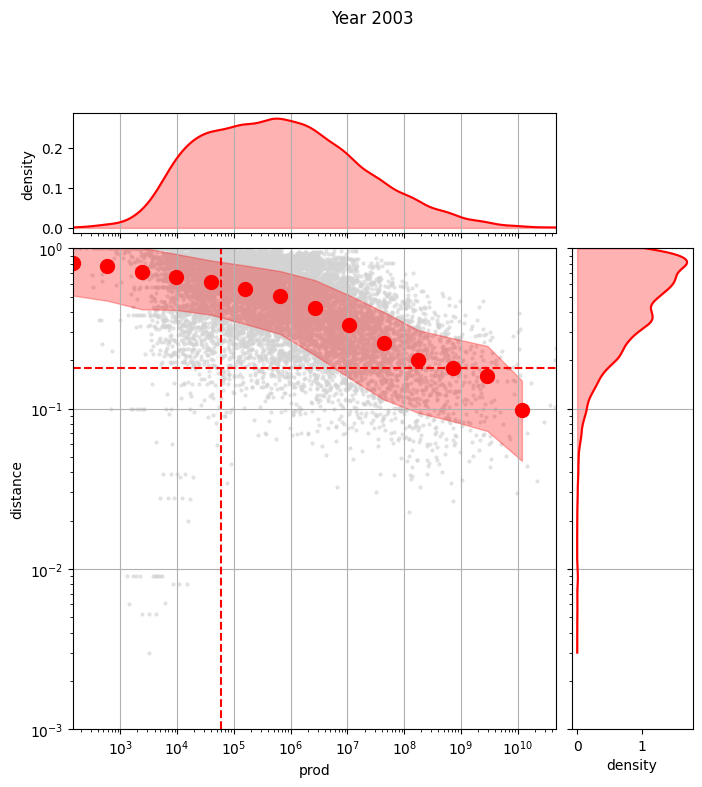

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/1282244744.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c1name'] = dflow['c1'].map(id2nameC)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/1282244744.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c2name'] = dflow['c2'].map(id2nameC)


In [26]:
y = 2003
df_year = df_long[df_long['year'] == y]

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(2, 2, 
                        width_ratios=[4, 1], 
                        height_ratios=[1, 4],
                        hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# --- plot principale ---
ax_main.scatter(df_year['prod'], df_year['distance'], color='lightgray', alpha=0.3, s=4)
xb, yb, ystd = logBinningFunction(df_year['prod'], df_year['distance'], 15)
ax_main.fill_between(xb[:-1], yb-ystd, yb+ystd, color='red', alpha=0.3)
ax_main.plot(xb[:-1], yb, 'o', markersize=10, color='red')
ax_main.set_xscale('log')
ax_main.set_yscale('log')
ax_main.set_ylim(0.001, 1)
ax_main.set_xlabel('prod')
ax_main.set_ylabel('distance')
ax_main.grid()

# --- KDE prod (in alto) ---
log_prod = np.log10(df_year['prod'].dropna())
log_prod = log_prod[np.isfinite(log_prod)]
kde_prod = gaussian_kde(log_prod)
x_grid = np.linspace(log_prod.min(), log_prod.max(), 300)
ax_top.plot(10**x_grid, kde_prod(x_grid), color='red')
ax_top.fill_between(10**x_grid, kde_prod(x_grid), alpha=0.3, color='red')
ax_top.set_xscale('log')
ax_top.set_ylabel('density')
ax_top.tick_params(labelbottom=False)
ax_top.grid(axis='x')

# --- KDE distance (a destra) ---
log_dist = np.log10(df_year['distance'].dropna())
log_dist = log_dist[np.isfinite(log_dist)]
kde_dist = gaussian_kde(log_dist)
y_grid = np.linspace(log_dist.min(), log_dist.max(), 300)
ax_right.plot(kde_dist(y_grid), 10**y_grid, color='red')
ax_right.fill_betweenx(10**y_grid, kde_dist(y_grid), alpha=0.3, color='red')
ax_right.set_yscale('log')
ax_right.set_xlabel('density')
ax_right.tick_params(labelleft=False)
ax_right.grid(axis='y')

q_prod = df_year['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year['distance'].quantile(0.10)  # bottom 25%
mask = (df_year['prod'] < q_prod) & (df_year['distance'] < q_dist)
ax_main.vlines(x=q_prod, ymin=0.001, ymax=1, color='red', linestyle='--')
ax_main.hlines(y=q_dist, xmin=df_year['prod'].min(), xmax=df_year['prod'].max(), color='red', linestyle='--')
ax_main.set_xlim(xmin=df_year['prod'].min(), xmax=df_year['prod'].max())
plt.suptitle(f'Year {y}', y=1.01)
plt.show()

import networkx as nx
dflow = df_year[mask]
dflow['c1name'] = dflow['c1'].map(id2nameC)
dflow['c2name'] = dflow['c2'].map(id2nameC)
G=nx.from_pandas_edgelist(dflow, source='c1name', target='c2name', create_using=nx.Graph())
nx.write_gexf(G, f'graph_{y}.gexf')

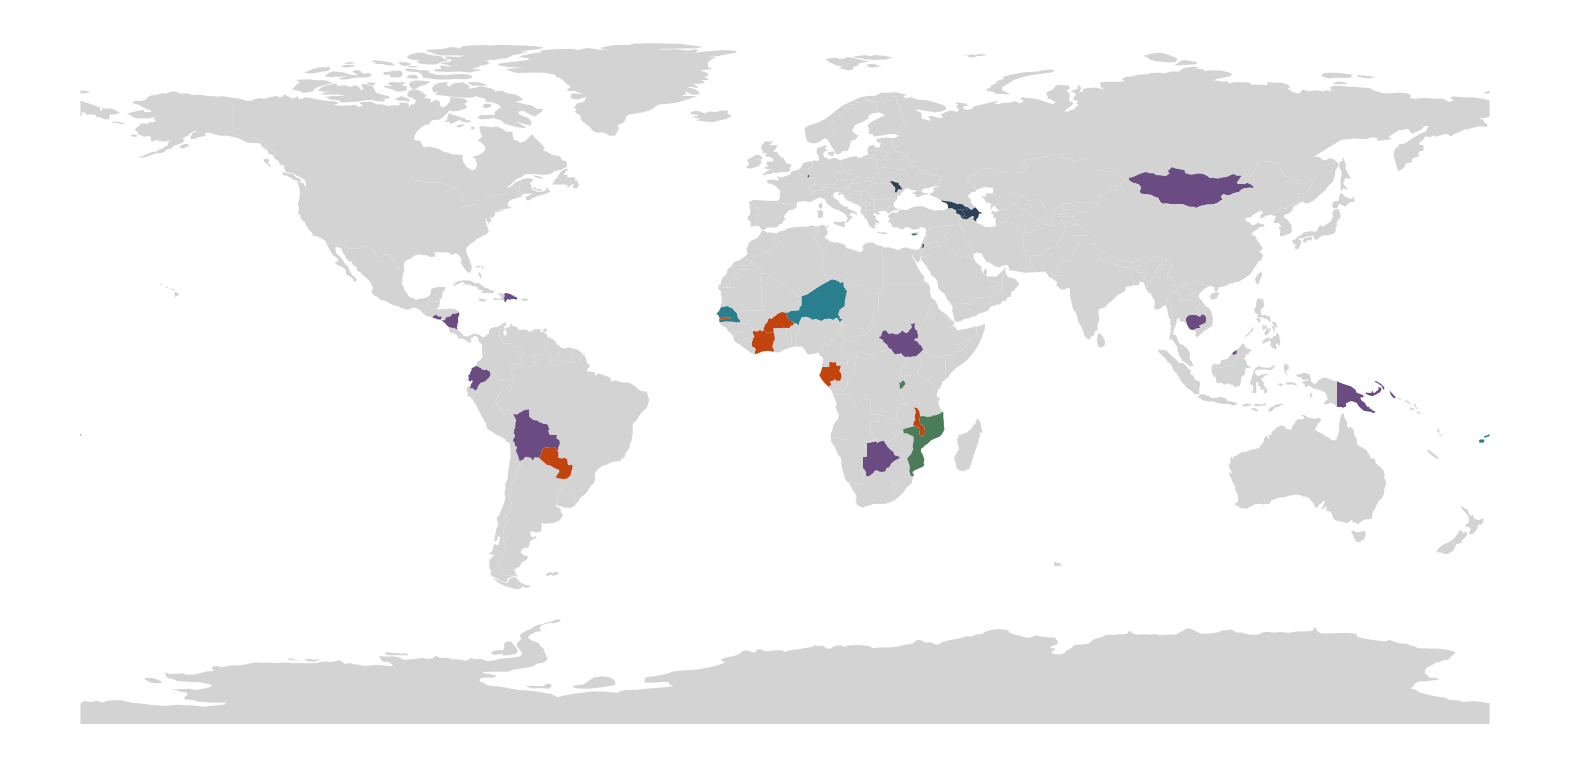

In [27]:
cc=nx.connected_components(G)
#transform in a dataframe
df_cc = pd.DataFrame({'country': list(G.nodes), 'component': [0]*len(G.nodes)})
for i, comp in enumerate(cc):
    if len(comp)>2:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = i+1 
    else:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = 0   

df_cc['ISO3']=df_cc['country'].map(name2iso3)

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
#merge with df_cc (quello non presente avrà component 0)
world = world.merge(df_cc, how="left", left_on="ISO_A3", right_on="ISO3")
world["component"] = world["component"].fillna(0)

colors = [
    "lightgray",
    "#2E4057",  # Blu notte
    "#C1440E",  # Terracotta
    "#4A7C59",  # Verde salvia
    "#8B5E3C",  # Marrone caldo
    "#6B4C82",  # Viola scuro
    "#C49A3C",  # Ocra dorata
    "#2A7F8F",  # Teal profondo
    "#B5432A",  # Rosso mattone
    "#5C7A3E",  # Verde oliva
    "#7A3B4B",  # Bordeaux
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=range(len(colors) + 1), ncolors=len(colors))

fig, ax = plt.subplots(figsize=(20, 10))
world.plot(column="component", ax=ax, cmap=cmap, norm=norm)
#remove axis
ax.set_axis_off()
plt.show()


/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


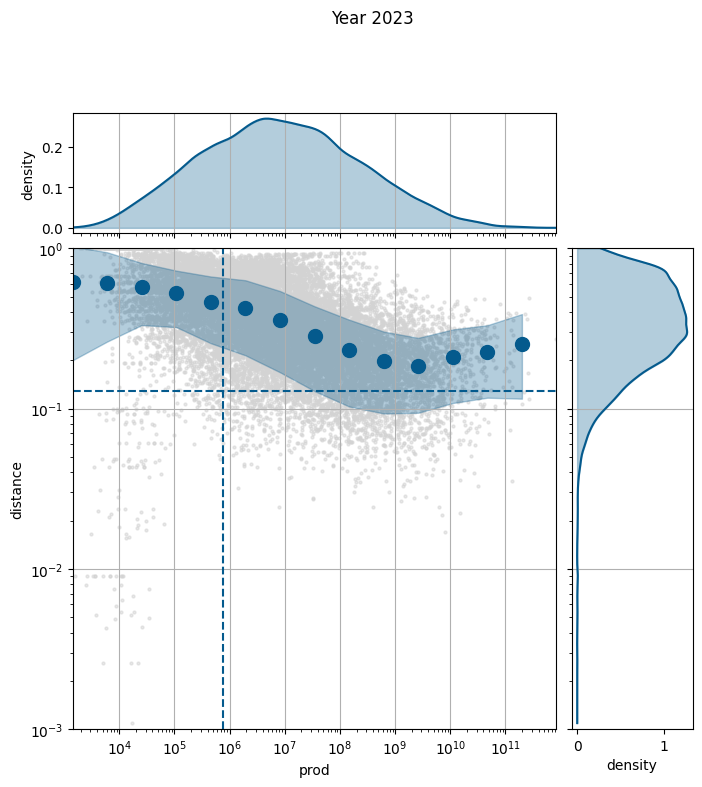

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/3266665738.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c1name'] = dflow['c1'].map(id2nameC)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/3266665738.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflow['c2name'] = dflow['c2'].map(id2nameC)


In [28]:
y = 2023
df_year = df_long[df_long['year'] == y]

color="#045A8D"

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(2, 2, 
                        width_ratios=[4, 1], 
                        height_ratios=[1, 4],
                        hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# --- plot principale ---
ax_main.scatter(df_year['prod'], df_year['distance'], color='lightgray', alpha=0.3, s=4)
xb, yb, ystd = logBinningFunction(df_year['prod'], df_year['distance'], 15)
ax_main.fill_between(xb[:-1], yb-ystd, yb+ystd, color=color, alpha=0.3)
ax_main.plot(xb[:-1], yb, 'o', markersize=10, color=color)
ax_main.set_xscale('log')
ax_main.set_yscale('log')
ax_main.set_ylim(0.001, 1)
ax_main.set_xlim(xmin=df_year['prod'].min(), xmax=df_year['prod'].max())
ax_main.set_xlabel('prod')
ax_main.set_ylabel('distance')
ax_main.grid()

# --- KDE prod (in alto) ---
log_prod = np.log10(df_year['prod'].dropna())
log_prod = log_prod[np.isfinite(log_prod)]
kde_prod = gaussian_kde(log_prod)
x_grid = np.linspace(log_prod.min(), log_prod.max(), 300)
ax_top.plot(10**x_grid, kde_prod(x_grid), color=color)
ax_top.fill_between(10**x_grid, kde_prod(x_grid), alpha=0.3, color=color)
ax_top.set_xscale('log')
ax_top.set_ylabel('density')
ax_top.tick_params(labelbottom=False)
ax_top.grid(axis='x')

# --- KDE distance (a destra) ---
log_dist = np.log10(df_year['distance'].dropna())
log_dist = log_dist[np.isfinite(log_dist)]
kde_dist = gaussian_kde(log_dist)
y_grid = np.linspace(log_dist.min(), log_dist.max(), 300)
ax_right.plot(kde_dist(y_grid), 10**y_grid, color=color)
ax_right.fill_betweenx(10**y_grid, kde_dist(y_grid), alpha=0.3, color=color)
ax_right.set_yscale('log')
ax_right.set_xlabel('density')
ax_right.tick_params(labelleft=False)
ax_right.grid(axis='y')

q_prod = df_year['prod'].quantile(0.25)      # bottom 25%
q_dist = df_year['distance'].quantile(0.10)  # bottom 25%
mask = (df_year['prod'] < q_prod) & (df_year['distance'] < q_dist)
ax_main.vlines(x=q_prod, ymin=0.001, ymax=1, color=color, linestyle='--')
ax_main.hlines(y=q_dist, xmin=df_year['prod'].min(), xmax=df_year['prod'].max(), color=color, linestyle='--')

plt.suptitle(f'Year {y}', y=1.01)
plt.show()

import networkx as nx
dflow = df_year[mask]
dflow['c1name'] = dflow['c1'].map(id2nameC)
dflow['c2name'] = dflow['c2'].map(id2nameC)
G=nx.from_pandas_edgelist(dflow, source='c1name', target='c2name', create_using=nx.Graph())
nx.write_gexf(G, f'graph_{y}.gexf')

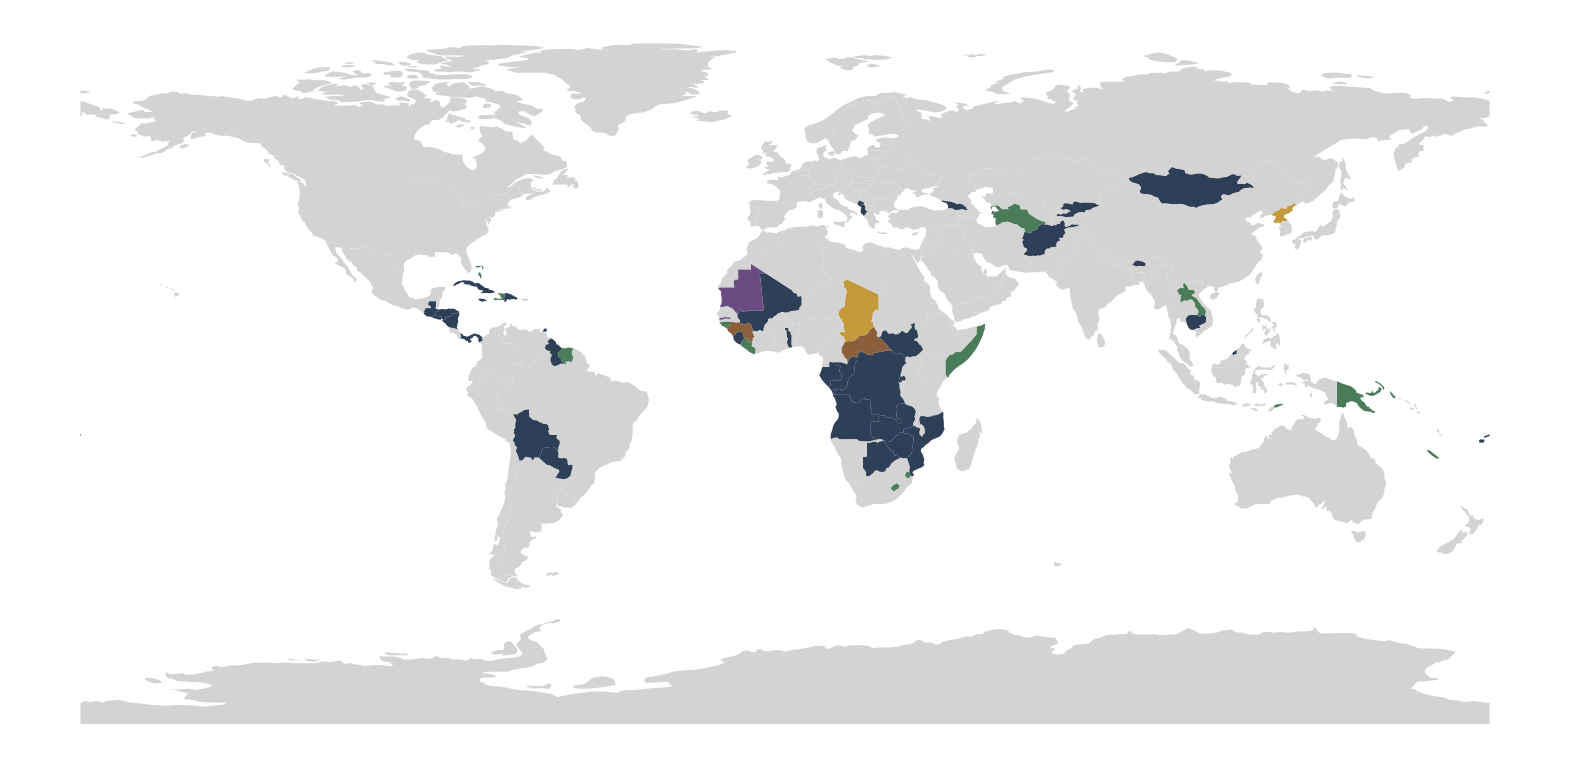

In [29]:
cc=nx.connected_components(G)
#transform in a dataframe
df_cc = pd.DataFrame({'country': list(G.nodes), 'component': [0]*len(G.nodes)})
for i, comp in enumerate(cc):
    if len(comp)>2:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = i+1 
    else:
        for node in comp:
            df_cc.loc[df_cc['country'] == node, 'component'] = 0   

df_cc['ISO3']=df_cc['country'].map(name2iso3)

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
#merge with df_cc (quello non presente avrà component 0)
world = world.merge(df_cc, how="left", left_on="ISO_A3", right_on="ISO3")
world["component"] = world["component"].fillna(0)

colors = [
    "lightgray",
    "#2E4057",  # Blu notte
    "#C1440E",  # Terracotta
    "#4A7C59",  # Verde salvia
    "#8B5E3C",  # Marrone caldo
    "#6B4C82",  # Viola scuro
    "#C49A3C",  # Ocra dorata
    "#2A7F8F",  # Teal profondo
    "#B5432A",  # Rosso mattone
    "#5C7A3E",  # Verde oliva
    "#7A3B4B",  # Bordeaux
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=range(len(colors) + 1), ncolors=len(colors))

fig, ax = plt.subplots(figsize=(20, 10))
world.plot(column="component", ax=ax, cmap=cmap, norm=norm)
#remove axis
ax.set_axis_off()
plt.show()


# Aspiration network

In [30]:
df_long['log_attr']=df_long['nP2'].apply(lambda x: np.log10(x) if x > 0 else np.nan)
df_long['c1name']=df_long['c1'].map(id2nameC)
df_long['c2name']=df_long['c2'].map(id2nameC)

alpha=0.5
df_long['mostRelevant']=df_long['log_attr']*(1/df_long['distance']**alpha)

In [31]:
df_long_red=df_long[(df_long['nP1']>100) & (df_long['nP2']>100)]

In [32]:
import numpy as np
df_long_red['log_attr']=df_long_red['nP2'].apply(lambda x: np.log10(x) if x > 0 else np.nan)
df_long_red['c1name']=df_long_red['c1'].map(id2nameC)
df_long_red['c2name']=df_long_red['c2'].map(id2nameC)

alpha=0.5
df_long_red['mostRelevant']=df_long_red['log_attr']*(1/df_long_red['distance']**alpha)

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/1158032743.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long_red['log_attr']=df_long_red['nP2'].apply(lambda x: np.log10(x) if x > 0 else np.nan)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/1158032743.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long_red['c1name']=df_long_red['c1'].map(id2nameC)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/1158032743.py:4: SettingWithCopyWarning: 
A 

In [33]:
import collections
dfPR=pd.DataFrame()
graphs={}

for y in df_long['year'].unique():
    alldd=pd.DataFrame()
    dfYear=df_long[df_long['year']==y]
    cc=list(dfYear['c1'].unique())
    for country in cc:
        dd=dfYear[dfYear['c1']==country]
        thisdd=dd[dd['nP1']<dd['nP2']].sort_values(by='distance',ascending=True).head(5)
        alldd=pd.concat([alldd, thisdd])
    DG=nx.from_pandas_edgelist(alldd, source='c1name', target='c2name', create_using=nx.DiGraph())
    graphs[y] = DG
    pr=nx.pagerank(DG)
    dfPR=pd.concat([dfPR, pd.DataFrame.from_dict(pr, orient='index', columns=[y])], axis=1)

In [34]:
def participation_ratio(dfPR):
    """
    Computes, for each year (column), the effective number of dominant
    countries (participation ratio) based on PageRank values.
    NaNs are excluded from the normalization for that year.
    """
    results = {}

    for year in dfPR.columns:
        pr = dfPR[year].dropna()

        if pr.empty:
            results[year] = np.nan
            continue

        # re-normalize so the values sum to 1 for that year
        # (in case NaNs were dropped or PR wasn't already normalized)
        p = pr / pr.sum()

        hhi = (p ** 2).sum()
        n_eff = 1 / hhi

        results[year] = n_eff

    n_eff_series = pd.Series(results, name="N_eff")

    # number of non-NaN countries per year, for the N_eff / n ratio
    n_countries = dfPR.notna().sum(axis=0)
    n_eff_relative = n_eff_series / n_countries

    out = pd.DataFrame({
        "N_eff": n_eff_series,
        "n_countries": n_countries,
        "N_eff_relative": n_eff_relative
    })

    return out


# --- usage ---
polycentrism_df = participation_ratio(dfPR)


In [35]:
dfPR_norm = dfPR.apply(lambda col: (col - col.mean()) / col.std(), axis=0)

# Maschera booleana: True se il paese è top-30 in almeno un anno
#top30_mask = dfPR_norm.apply(lambda col: col.rank(ascending=False) <= 10)
#countries_ever_top30 = top30_mask.any(axis=1)
#df_filtered = dfPR_norm[countries_ever_top30]

top20_mask = dfPR.apply(lambda col: col.rank(ascending=False) <= 10)
countries_5years_top20 = top20_mask.sum(axis=1) >= 5
df_filtered = dfPR[countries_5years_top20]


# Ordina per primo anno
first_year = df_filtered.columns[0]
df_sorted = df_filtered.sort_values(by=first_year, ascending=False)

In [36]:
dfPR_norm

,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
United Arab Emirates,-0.497181,-0.490846,-0.481615,-0.487842,-0.456507,-0.503899,-0.482467,-0.401703,-0.433748,-0.244633,...,-0.249510,-0.170842,-0.118660,-0.244146,-0.236617,-0.274480,-0.308238,-0.385638,-0.343927,-0.443734
Viet Nam,-0.437023,-0.490846,-0.481615,-0.458429,-0.456507,-0.439532,-0.482467,-0.363557,-0.406215,-0.368616,...,-0.171027,-0.233482,-0.209307,-0.329971,-0.328371,-0.130166,-0.228994,-0.192078,-0.217575,-0.278248
"Korea, Republic of",-0.396715,-0.382160,-0.330514,-0.336640,-0.299833,-0.292326,-0.221862,-0.210342,-0.185707,-0.233295,...,-0.006141,-0.013954,-0.189055,-0.109862,-0.108005,-0.053223,-0.028362,-0.051765,-0.015849,-0.056538
Nepal,-0.315827,-0.396494,-0.481615,-0.371053,-0.421989,-0.439532,-0.420402,-0.424026,-0.465963,-0.396139,...,-0.285379,-0.368866,-0.253002,-0.228520,-0.032573,-0.087369,-0.135773,-0.292690,-0.099169,-0.012360
Singapore,-0.330688,-0.382506,-0.352473,-0.383751,-0.387472,-0.334261,-0.082117,-0.394650,-0.386392,-0.406294,...,-0.126955,-0.156189,-0.295648,-0.242651,-0.282950,-0.257287,-0.270552,-0.314266,-0.329562,-0.352012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Antigua and Barbuda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.137736,-0.204258
Mauritania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.420258,-0.421473
Haiti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.443021,-0.443734
Chad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.364954


In [37]:
def white_to_color(color, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"white_to_{color}",
        [(0.0, "white"), (1, color)],
        N=n
    )

cmap = white_to_color("#7A1F2B")
cmap = mcolors.LinearSegmentedColormap.from_list(name="test", colors=[(0, "white"), (0.4, "#E0929C"), (0.8, "#7A1F2B"), (1, "#472025")])
# cmap = mcolors.LinearSegmentedColormap.from_list(name="test", colors=[(0, "#FFE8EB"), (0.4, "#E0929C"), (0.8, "#7A1F2B"), (1, "#472025")])

In [51]:
dfPR['medio'] = dfPR.mean(axis=1)
dfPR.sort_values(by='medio', ascending=False, inplace=True)
dfPRplot = dfPR.head(20)
del dfPRplot['medio']

dfPRplot = (
    dfPRplot
    .reset_index(names=["country"])
    .replace({"United Kingdom of Great Britain and Northern Ireland": "UK",
              "Netherlands, Kingdom of the": "Netherlands",
              "Taiwan, Province of China": "Taiwan",
              "United States of America": "US"})
    .set_index("country")
)

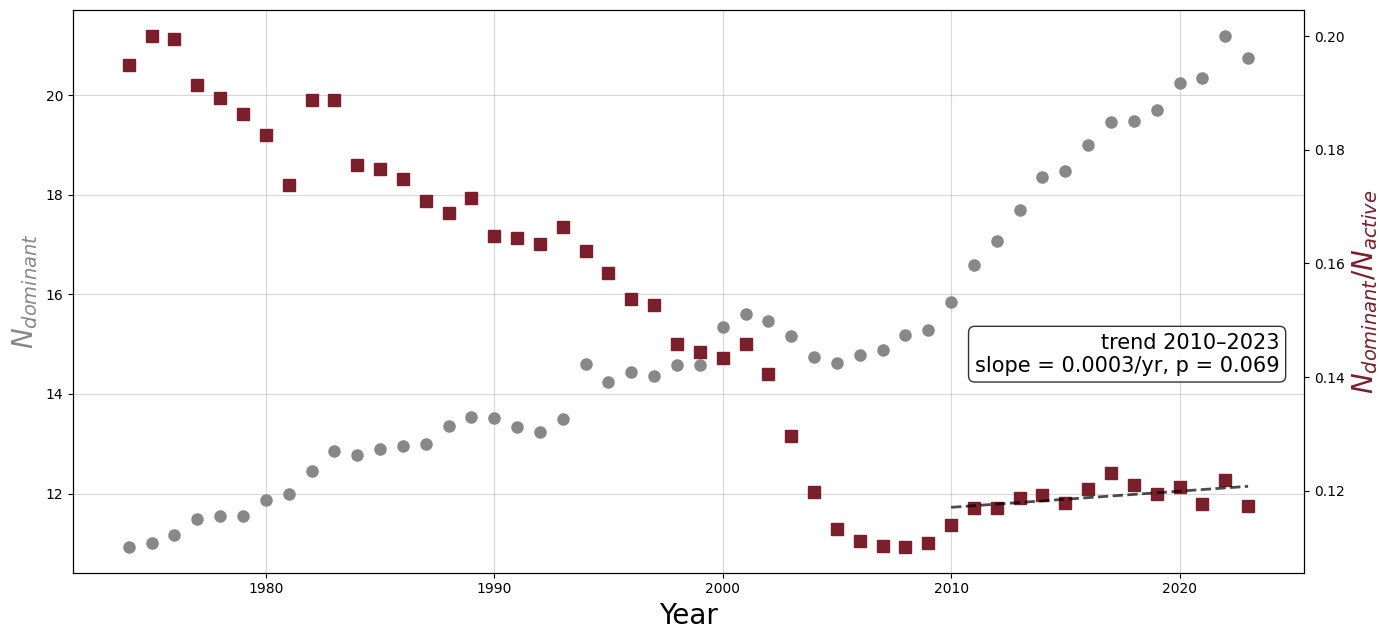

In [52]:
from scipy import stats
fig, ax1 = plt.subplots(figsize=(14, 6.5))

# N_eff on the left axis
#ax1.plot(polycentrism_df.index, polycentrism_df['N_eff'], 'ok', markersize=8)
ax1.plot(polycentrism_df.index, polycentrism_df['N_eff'], 'o',color='#888888', markersize=8,alpha=1)
ax1.set_xlabel('Year', size=20)
ax1.set_ylabel(r'$N_{dominant}$', size=20, color='#888888')
ax1.grid(alpha=0.5)

# N_eff_relative on the right axis
ax2 = ax1.twinx()
#ax2.plot(polycentrism_df.index, polycentrism_df['N_eff_relative'], 'sk', markersize=8)
ax2.plot(polycentrism_df.index, polycentrism_df['N_eff_relative'], 's', color='#7A1F2B', markersize=8)
ax2.set_ylabel(r'$N_{dominant}/N_{active}$', size=20, color='#7A1F2B')

# --- trend line post-2010 su N_eff_relative ---
post2010 = polycentrism_df.loc[polycentrism_df.index >= 2010, 'N_eff_relative'].dropna()
years = post2010.index.values
values = post2010.values

slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
fit_line = slope * years + intercept

ax2.plot(years, fit_line, '--', color='black', linewidth=2, alpha=0.7, zorder=2)

# annotazione con p-value
ax2.annotate(
    f"trend 2010–{years.max()}\nslope = {slope:.4f}/yr, p = {p_value:.3f}",
    xy=(years[-1], fit_line[-1]),
    xytext=(0.98, 0.35), textcoords='axes fraction',
    ha='right', va='bottom',
    fontsize=15, color='black',
    bbox=dict(boxstyle='round', fc='white', ec='black', alpha=0.8)
)

plt.tight_layout()
# plt.savefig('PR_polycentrism_trends.svg', format='svg')
plt.show()



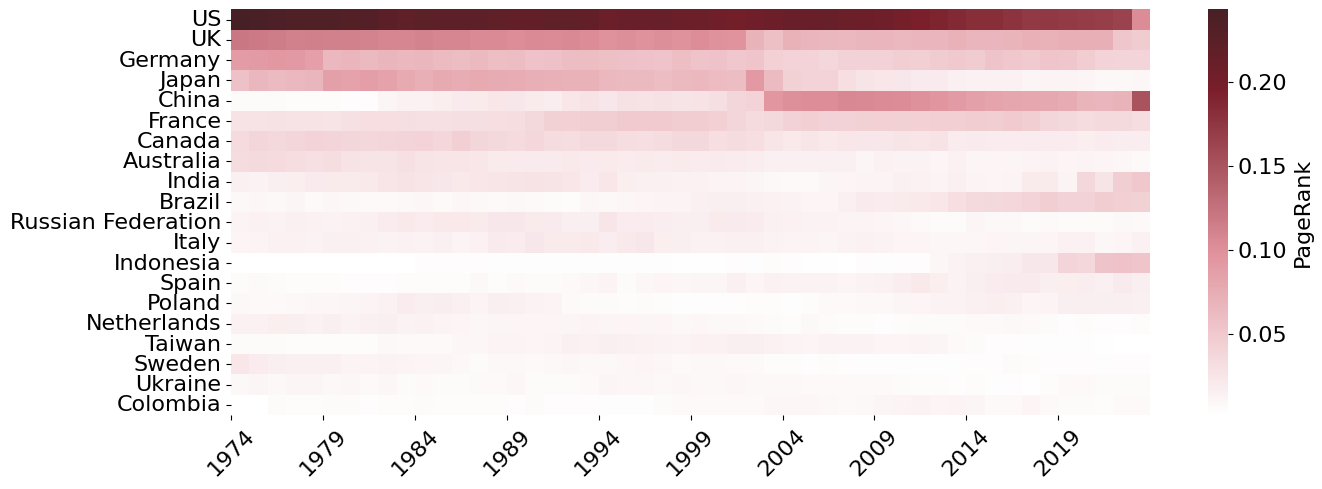

In [53]:
# Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
hm =sns.heatmap(dfPRplot, 
            # cmap='YlOrRd',
            cmap=cmap,
            ax=ax,
            cbar_kws={'label': 'PageRank'})

#sns.heatmap(np.log10(df_sorted), 
#            cmap='YlOrRd',
#            ax=ax,
#            cbar_kws={'label': 'log10(PageRank)'})
cbar = hm.collections[0].colorbar
cbar.set_label('PageRank', fontsize=16)

cbar.ax.tick_params(labelsize=16)

ax.set_xlabel(None)
ax.set_ylabel(None)
# ax.set_title('PageRank over time')

# Riduce i tick sull'asse x per leggibilità
years = df_sorted.columns
ax.set_xticks(range(0, len(years), 5))
ax.set_xticklabels(years[::5], size=16, rotation=45)
ax.set_yticklabels(ax.get_yticklabels(), size=16)

# cbar.set_ylabel(r"Distance $W_1^{\mathcal{T}}$", fontsize=16, rotation=-90, )
# cbar.tick_params(labelsize=18, labelleft=True, labelright=False, right=False, left=True)


plt.tight_layout()
# fig.savefig(f"../pagerank_v1.jpg", dpi=1000, bbox_inches='tight')

In [54]:
alpha = 0.5
df_long_red['mostRelevant'] = df_long_red['log_attr'] * (1 / df_long_red['distance']**alpha)
dfPR = pd.DataFrame()
graphs = {}
ntop = 5

for y in df_long_red['year'].unique():
    alldd = pd.DataFrame()
    dfYear = df_long_red[df_long_red['year']==y]
    cc = list(dfYear['c1'].unique())
    for country in cc:
        dd = dfYear[dfYear['c1']==country]
        thisdd = dd[dd['nP1']<dd['nP2']].sort_values(by='mostRelevant', ascending=False).head(ntop)
        alldd = pd.concat([alldd, thisdd])
    DG = nx.from_pandas_edgelist(alldd, source='c1name', target='c2name', create_using=nx.DiGraph())
    graphs[y] = DG
    pr = nx.pagerank(DG)
    dfPR = pd.concat([dfPR, pd.DataFrame.from_dict(pr, orient='index', columns=[y])], axis=1)

polycentrism_df = participation_ratio(dfPR)

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_24304/1027376181.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long_red['mostRelevant'] = df_long_red['log_attr'] * (1 / df_long_red['distance']**alpha)


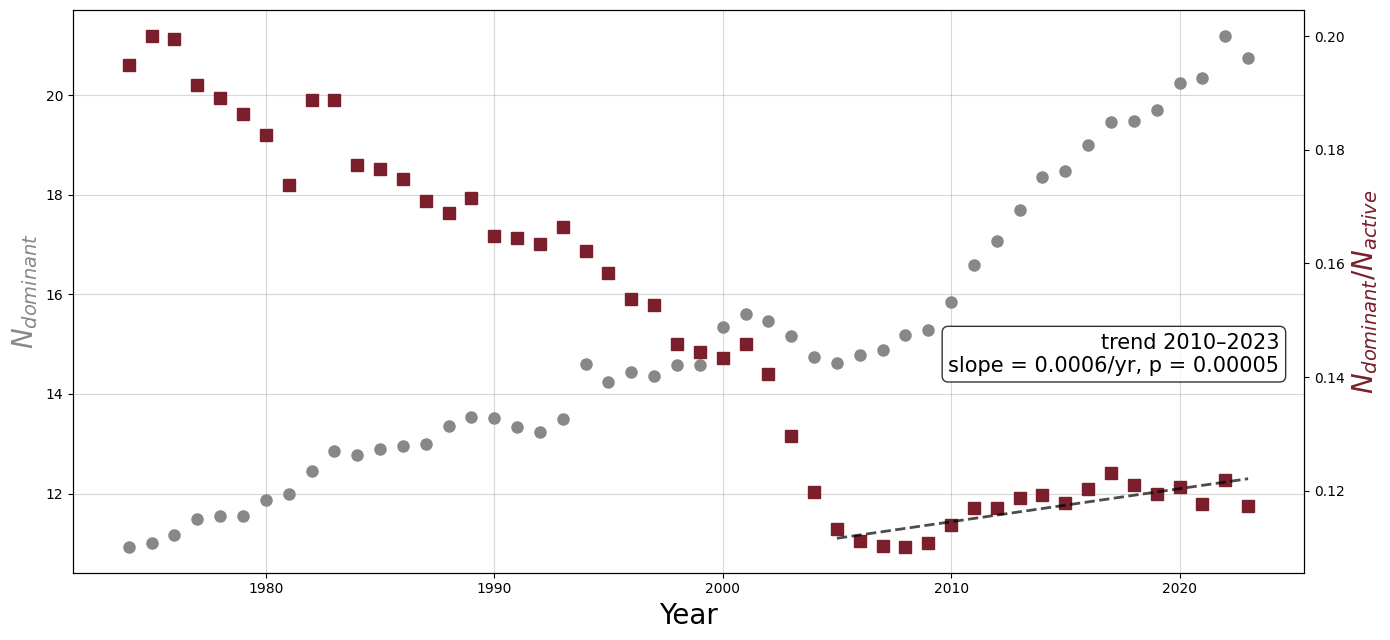

In [55]:
from scipy import stats
fig, ax1 = plt.subplots(figsize=(14, 6.5))

# N_eff on the left axis
#ax1.plot(polycentrism_df.index, polycentrism_df['N_eff'], 'ok', markersize=8)
ax1.plot(polycentrism_df.index, polycentrism_df['N_eff'], 'o',color='#888888', markersize=8,alpha=1)
ax1.set_xlabel('Year', size=20)
ax1.set_ylabel(r'$N_{dominant}$', size=20, color='#888888')
ax1.grid(alpha=0.5)

# N_eff_relative on the right axis
ax2 = ax1.twinx()
#ax2.plot(polycentrism_df.index, polycentrism_df['N_eff_relative'], 'sk', markersize=8)
ax2.plot(polycentrism_df.index, polycentrism_df['N_eff_relative'], 's', color='#7A1F2B', markersize=8)
ax2.set_ylabel(r'$N_{dominant}/N_{active}$', size=20, color='#7A1F2B')

# --- trend line post-2010 su N_eff_relative ---
post2010 = polycentrism_df.loc[polycentrism_df.index >= 2005, 'N_eff_relative'].dropna()
years = post2010.index.values
values = post2010.values

slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
fit_line = slope * years + intercept

ax2.plot(years, fit_line, '--', color='black', linewidth=2, alpha=0.7, zorder=2)

# annotazione con p-value
ax2.annotate(
    f"trend 2010–{years.max()}\nslope = {slope:.4f}/yr, p = {p_value:.5f}",
    xy=(years[-1], fit_line[-1]),
    xytext=(0.98, 0.35), textcoords='axes fraction',
    ha='right', va='bottom',
    fontsize=15, color='black',
    bbox=dict(boxstyle='round', fc='white', ec='black', alpha=0.8)
)

plt.tight_layout()
plt.savefig('PR_polycentrism_trends.svg', format='svg')
plt.show()



In [ ]:
# N_eff on the left axis
#ax1.plot(polycentrism_df.index, polycentrism_df['N_eff'], 'ok', markersize=8)
ax1.plot(polycentrism_df.index, polycentrism_df['N_eff'], 'o',color='#888888', markersize=8,alpha=1)
ax1.set_xlabel('Year', size=20)
ax1.set_ylabel(r'$N_{dominant}$', size=20, color='#888888')
ax1.grid(alpha=0.5)

# N_eff_relative on the right axis
ax2 = ax1.twinx()
#ax2.plot(polycentrism_df.index, polycentrism_df['N_eff_relative'], 'sk', markersize=8)
ax2.plot(polycentrism_df.index, polycentrism_df['N_eff_relative'], 's', color='#7A1F2B', markersize=8)
ax2.set_ylabel(r'$N_{dominant}/N_{active}$', size=20, color='#7A1F2B')

# --- trend line post-2010 su N_eff_relative ---
post2010 = polycentrism_df.loc[polycentrism_df.index >= 2005, 'N_eff_relative'].dropna()
years = post2010.index.values
values = post2010.values

slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
fit_line = slope * years + intercept

ax2.plot(years, fit_line, '--', color='black', linewidth=2, alpha=0.7, zorder=2)

# annotazione con p-value
ax2.annotate(
    f"trend 2010–{years.max()}\nslope = {slope:.4f}/yr, p = {p_value:.5f}",
    xy=(years[-1], fit_line[-1]),
    xytext=(0.98, 0.35), textcoords='axes fraction',
    ha='right', va='bottom',
    fontsize=15, color='black',
    bbox=dict(boxstyle='round', fc='white', ec='black', alpha=0.8)
)

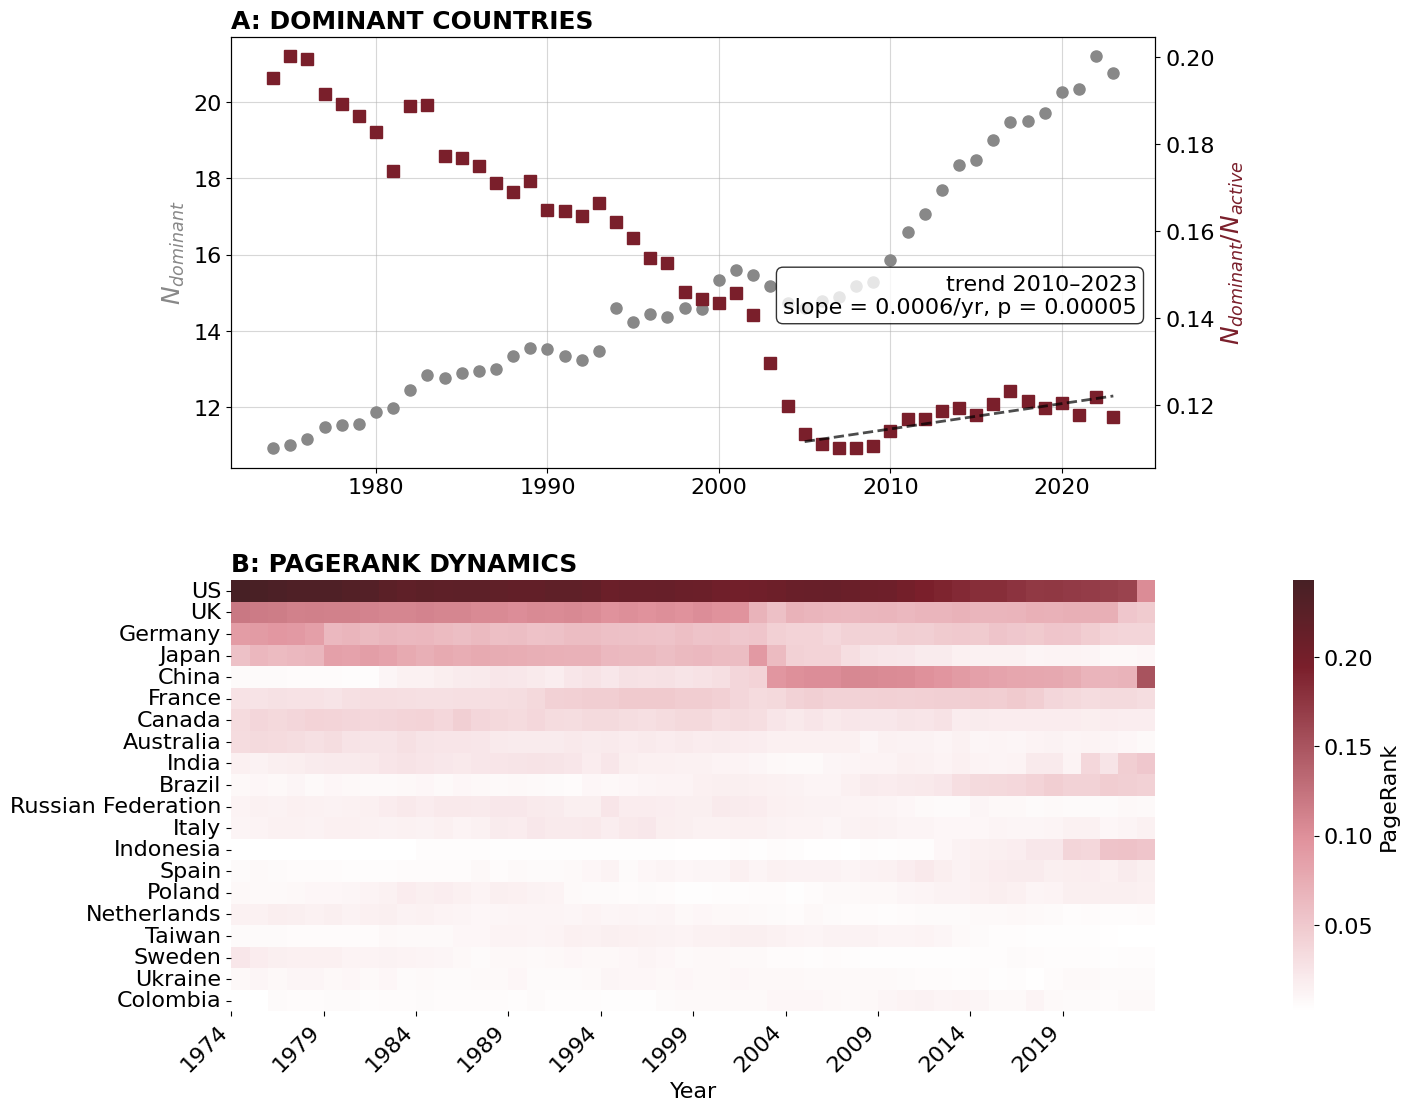

In [60]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax_heat) = plt.subplots(
    2, 1,
    figsize=(14, 11),
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.1},
    constrained_layout=True
)

# ======================================================
# TOP PANEL
# ======================================================

ax1.plot(polycentrism_df.index, polycentrism_df['N_eff'], 'o',color='#888888', markersize=8,alpha=1)

ax1.set_title("A: DOMINANT COUNTRIES", fontsize=18, fontweight="bold", loc="left")
ax1.set_ylabel(r"$N_{dominant}$", fontsize=18, color="#888888")
ax1.grid(alpha=0.5)
ax1.tick_params(labelsize=16)

# right axis
ax2 = ax1.twinx()
#ax2.plot(polycentrism_df.index, polycentrism_df['N_eff_relative'], 'sk', markersize=8)
ax2.plot(polycentrism_df.index, polycentrism_df['N_eff_relative'], 's', color='#7A1F2B', markersize=8)
ax2.set_ylabel(r'$N_{dominant}/N_{active}$', size=18, color='#7A1F2B')
ax2.tick_params(labelsize=16)


# trend
post2010 = polycentrism_df.loc[polycentrism_df.index >= 2005, 'N_eff_relative'].dropna()
years = post2010.index.values
values = post2010.values

slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
fit_line = slope * years + intercept

ax2.plot(years, fit_line, '--', color='black', linewidth=2, alpha=0.7, zorder=2)

ax2.annotate(
    f"trend 2010–{years.max()}\nslope = {slope:.4f}/yr, p = {p_value:.5f}",
    xy=(years[-1], fit_line[-1]),
    xytext=(0.98, 0.35), textcoords='axes fraction',
    ha='right', va='bottom',
    fontsize=16, color='black',
    bbox=dict(boxstyle='round', fc='white', ec='black', alpha=0.8)
)

# ======================================================
# BOTTOM PANEL
# ======================================================

hm = sns.heatmap(
    dfPRplot,
    cmap=cmap,
    ax=ax_heat,
    cbar_kws={"label": "PageRank"}
)

cbar = hm.collections[0].colorbar
cbar.set_label("PageRank", fontsize=16)
cbar.ax.tick_params(labelsize=16)

ax_heat.set_xlabel("Year", fontsize=16)
ax_heat.set_ylabel("")

years = dfPRplot.columns

step = 5
ax_heat.set_xticks(range(0, len(years), step))
ax_heat.set_xticklabels(
    years[::step],
    rotation=45,
    ha="right",
    fontsize=16
)
ax_heat.set_title("B: PAGERANK DYNAMICS", fontsize=18, fontweight="bold", loc="left")
ax_heat.tick_params(axis="y", labelsize=16)

# from matplotlib.patches import Rectangle

# Force matplotlib to calculate final positions
# fig.canvas.draw()


# # ---------- Panel A frame ----------
# pos = ax1.get_position()

# frame_A = Rectangle(
#     (pos.x0 - 0.02, pos.y0 - 0.08),
#     pos.width + 0.04,
#     pos.height + 0.15,
#     transform=fig.transFigure,
#     fill=False,
#     linewidth=1.5,
#     edgecolor="black"
# )

# fig.add_artist(frame_A)


# # ---------- Panel B frame ----------
# pos = ax_heat.get_position()

# frame_B = Rectangle(
#     (pos.x0-0.25, pos.y0 - 0.1),
#     pos.width + 0.45,
#     pos.height + 0.18,
#     transform=fig.transFigure,
#     fill=False,
#     linewidth=1.5,
#     edgecolor="black"
# )

# fig.add_artist(frame_B)

plt.savefig("../images/pagerank_dominant.jpg", dpi=1000, bbox_inches='tight')

In [58]:
# nx.write_gexf(graphs[1983], f'graph_{1983}.gexf')
# nx.write_gexf(graphs[2023], f'graph_{2023}.gexf')
# nx.write_gexf(graphs[2003], f'graph_{2003}.gexf')

In [45]:
df_long

,year,c1,c2,distance,nP1,nP2,prod,log_attr,c1name,c2name,mostRelevant
0,1974,AE,AM,1.000000,36,49,1764,1.690196,United Arab Emirates,Armenia,1.690196
1,1974,AM,AE,1.000000,49,36,1764,1.556303,Armenia,United Arab Emirates,1.556303
2,1974,AE,AR,0.765204,36,454,16344,2.657056,United Arab Emirates,Argentina,3.037471
3,1974,AR,AE,0.765204,454,36,16344,1.556303,Argentina,United Arab Emirates,1.779121
4,1974,AE,AT,0.752202,36,902,32472,2.955207,United Arab Emirates,Austria,3.407381
...,...,...,...,...,...,...,...,...,...,...,...
970441,2023,ZM,ZA,0.194257,1583,32250,51051750,4.508530,Zambia,South Africa,10.229326
970442,2023,ZA,ZW,0.181795,32250,1911,61629750,3.281261,South Africa,Zimbabwe,7.695727
970443,2023,ZW,ZA,0.181795,1911,32250,61629750,4.508530,Zimbabwe,South Africa,10.574111
970444,2023,ZM,ZW,0.167167,1583,1911,3025113,3.281261,Zambia,Zimbabwe,8.025375


In [38]:
df_long_cl=df_long[(df_long['nP1']>500) & (df_long['nP2']>500)]

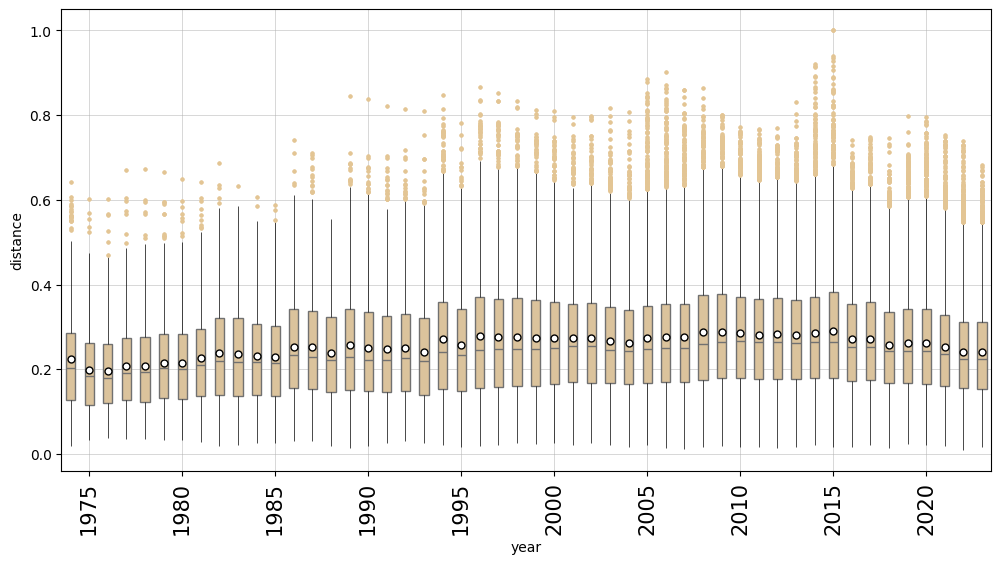

In [39]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_long_cl, x='year', y='distance', order=years,
            color='#e3c594', width=0.5, showfliers=True, showmeans=True,
            meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"},
            whiskerprops={"color":"black", "linewidth":0.5},
            capprops={"color":"black", "linewidth":0},
            flierprops={"marker":"o", "markerfacecolor":"#e3c594", "markeredgecolor":"#e3c594", "markersize":2},
            saturation=0.8)

tick_positions = [i for i, y in enumerate(years) if int(y) % 5 == 0]
tick_labels = [y for y in years if int(y) % 5 == 0]
plt.xticks(ticks=tick_positions, labels=tick_labels, size=15, rotation=90)

plt.grid( linewidth=0.5, alpha=0.7)
plt.show()

In [40]:
import pandas as pd

In [41]:
df=pd.read_csv('df_mapping_art.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'df_mapping_art.csv'

In [ ]:
df

,country,year,static_cluster,dynamic_cluster
0,AU,1983,0,1
1,BR,1983,0,1
2,CA,1983,0,1
3,CL,1983,0,1
4,CO,1983,0,1
...,...,...,...,...
781,VN,2023,2,7
782,ZA,2023,2,7
783,BF,2023,3,-1
784,BJ,2023,3,-1


In [ ]:
df['countryName']=df['country'].map(id2nameC)

In [ ]:
yy=2008
dfy=df[df['year']==yy]
clust=set(dfy['dynamic_cluster'].unique())
for i in clust:
    print(i)
    print(dfy[dfy['dynamic_cluster']==i]['countryName'].unique())

1
['Argentina' 'Austria' 'Australia' 'Belgium' 'Brazil' 'Canada'
 'Switzerland' 'Cuba' 'Germany' 'Denmark' 'Spain' 'Finland' 'France'
 'United Kingdom of Great Britain and Northern Ireland' 'Hungary'
 'Ireland' 'Israel' 'Iceland' 'Italy' 'Lebanon' 'Morocco' 'Mexico'
 'Nigeria' 'Netherlands, Kingdom of the' 'Norway' 'New Zealand' 'Qatar'
 'Serbia' 'Saudi Arabia' 'Sweden' 'Tunisia' 'Türkiye'
 'United States of America']
4
['Armenia' 'Azerbaijan' 'Bangladesh' 'Bulgaria' 'Belarus' 'China'
 'Czechia' 'Egypt' 'Georgia' 'Greece' 'India' 'Iraq'
 'Iran, Islamic Republic of' 'Jordan' 'Japan' 'Korea, Republic of'
 'Kuwait' 'Sri Lanka' 'Malaysia' 'Oman' 'Pakistan' 'Romania'
 'Russian Federation' 'Singapore' 'Slovakia' 'Thailand' 'Tajikistan'
 'Taiwan, Province of China' 'Ukraine' 'Uzbekistan']
6
['Bolivia, Plurinational State of' 'Chile' 'Colombia' 'Costa Rica'
 'Ecuador' 'Ghana' 'Croatia' 'Indonesia' 'Kenya' 'Luxembourg' 'Peru'
 'Philippines' 'Réunion' 'Uruguay' 'Venezuela, Bolivarian Republic of